# Projet REXIA -- Responsible and Explainable AI

## Partie 1/3 : Donnees tabulaires

Analyse du jeu de donnees RH anonymise. La variable cible `label` indique :
- **0** : l'employe n'a pas demissionne dans les 6 prochains mois
- **1** : l'employe a demissionne dans les 6 prochains mois

## 0. Imports et configuration

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -- Configuration globale des graphiques --
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
DATA_PATH = "../data/RH_dataset.csv"
CSV_SEPARATOR = ";"

LABEL_COL = "label"
LABEL_NAMES = {0: "Non-demission", 1: "Demission"}

## Fonctions utilitaires

In [38]:
def load_dataset(path: str, separator: str = ";") -> pd.DataFrame:
    """Charge le jeu de donnees CSV et retourne un DataFrame."""
    return pd.read_csv(path, sep=separator)


def plot_countplot(
    data: pd.DataFrame,
    column: str,
    title: str,
    hue: str | None = None,
    rotate_labels: int = 0,
    figsize: tuple[int, int] = (12, 5),
    order: list | None = None,
) -> None:
    """Affiche un diagramme en barres pour une colonne categorielle."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.countplot(data=data, x=column, hue=hue, order=order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Effectif")
    if rotate_labels:
        ax.tick_params(axis="x", rotation=rotate_labels)
    plt.tight_layout()
    plt.show()


def plot_distribution(
    data: pd.DataFrame,
    column: str,
    title: str,
    hue: str | None = None,
    bins: int = 30,
    figsize: tuple[int, int] = (12, 5),
) -> None:
    """Affiche un histogramme avec courbe de densite pour une colonne numerique."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=data, x=column, hue=hue, bins=bins, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel("Effectif")
    plt.tight_layout()
    plt.show()


def plot_boxplot_by_label(
    data: pd.DataFrame,
    column: str,
    label_col: str = LABEL_COL,
    title: str = "",
    figsize: tuple[int, int] = (10, 5),
) -> None:
    """Affiche un boxplot d'une variable numerique ventile par la variable cible."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(data=data, x=label_col, y=column, ax=ax)
    ax.set_title(title or f"Distribution de '{column}' par classe")
    ax.set_xlabel("Classe (label)")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()


def display_summary_table(data: pd.DataFrame) -> pd.DataFrame:
    """Retourne un DataFrame recapitulatif : type, nb valeurs uniques, min, max, manquantes."""
    summary = pd.DataFrame({
        "Type": data.dtypes,
        "Valeurs uniques": data.nunique(),
        "Valeurs manquantes": data.isnull().sum(),
        "% manquantes": (data.isnull().sum() / len(data) * 100).round(2),
        "Exemple": data.iloc[0],
    })
    return summary

---
## 1. Analyse du jeu de données

### 1.1 Chargement et aperçu général

In [39]:
df = load_dataset(DATA_PATH, CSV_SEPARATOR)

print(f"Dimensions du jeu de donnees : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")
df.head(10)

Dimensions du jeu de donnees : 23857 lignes, 14 colonnes



,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.910000,0.970000,27,30,1,1,3199,Marié(e),0,32,0
1,Production,35.119999,22.690001,14.830000,16.299999,7,45,1,2,3861,Marié(e),1,1890,0
2,Production,25.299999,22.139999,17.309999,17.790001,28,49,1,2,4324,PACS,1,1847,0
3,Production,5.240000,5.100000,1.020000,1.750000,27,24,0,1,2641,Célibataire,0,2619,1
4,Production,35.919998,22.840000,8.050000,9.000000,7,46,1,2,5072,Marié(e),1,1963,0
5,Production,30.410000,29.049999,3.350000,4.290000,28,40,1,1,3510,PACS,1,2642,0
6,Commercial/Business,13.840000,32.410000,8.890000,42.509998,28,72,1,3,7223,Marié(e),1,318,0
7,Etudes & Technique,34.799999,22.790001,9.480000,10.580000,28,45,1,2,4132,Marié(e),1,2132,0
8,Etudes & Technique,80.220001,24.180000,8.090000,35.349998,28,65,0,2,4773,Divorcé(e),1,880,0
9,Etudes & Technique,5.190000,2.780000,1.420000,10.100000,28,42,0,2,4517,Union libre,1,676,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23857 entries, 0 to 23856
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Famille d'emploi              23857 non-null  object 
 1   Dernière promotion (mois)     23857 non-null  float64
 2   Dernière augmentation (mois)  23857 non-null  float64
 3   Début de contrat (années)     23857 non-null  float64
 4   Ancienneté groupe (années)    23857 non-null  float64
 5   Etablissement                 23857 non-null  int64  
 6   Âge (années)                  23857 non-null  int64  
 7   Parent                        23857 non-null  int64  
 8   Niveau hiérarchique           23857 non-null  int64  
 9   Salaire (Euros)               23857 non-null  int64  
 10  Statut marital                23857 non-null  object 
 11  Véhicule                      23857 non-null  int64  
 12  matricule                     23857 non-null  int64  
 13  l

Il n'y a pas de données manquantes.

In [41]:
display_summary_table(df)

,Type,Valeurs uniques,Valeurs manquantes,% manquantes,Exemple
Famille d'emploi,object,8,0,0.0,Production
Dernière promotion (mois),float64,7670,0,0.0,8.51
Dernière augmentation (mois),float64,2934,0,0.0,7.9
Début de contrat (années),float64,2433,0,0.0,0.91
Ancienneté groupe (années),float64,3660,0,0.0,0.97
Etablissement,int64,35,0,0.0,27
Âge (années),int64,74,0,0.0,30
Parent,int64,2,0,0.0,1
Niveau hiérarchique,int64,4,0,0.0,1
Salaire (Euros),int64,4901,0,0.0,3199


In [42]:
df.describe().round(2)

,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Véhicule,matricule,label
count,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00,23857.00
mean,29.46,7.93,7.53,11.63,20.19,41.77,0.72,1.55,4168.40,0.51,1361.26,0.03
std,25.50,7.55,5.99,9.22,9.30,11.01,0.45,0.66,1657.83,0.50,794.18,0.18
min,0.00,0.00,0.00,0.00,0.00,20.00,0.00,1.00,2134.00,0.00,0.00,0.00
25%,10.59,3.18,2.30,3.80,11.00,34.00,0.00,1.00,3197.00,0.00,655.00,0.00
50%,21.22,5.88,6.28,9.87,26.00,41.00,1.00,1.00,3629.00,1.00,1371.00,0.00
75%,41.40,10.34,11.07,16.32,28.00,49.00,1.00,2.00,4511.00,1.00,2072.00,0.00
max,152.97,84.05,33.12,45.62,36.00,100.00,1.00,4.00,18137.00,2.00,2675.00,1.00


**Observations generales :**

- Le jeu de donnees contient **23 857 lignes** et **14 colonnes**. Il n'y a **aucune valeur manquante**.
- **Variables categorielles** (2) : `Famille d'emploi` (8 modalites), `Statut marital` (9 modalites).
- **Variables numeriques continues** (4) : `Derniere promotion (mois)`, `Derniere augmentation (mois)`, `Debut de contrat (annees)`, `Anciennete groupe (annees)`.
- **Variables numeriques discretes / binaires** : `Etablissement` (35 valeurs), `Age (annees)`, `Parent` (0/1), `Niveau hierarchique` (1-4), `Salaire (Euros)`, `Vehicule` (0/1 principalement, 4 cas a 2), `matricule` (identifiant unique), `label` (cible).
- La colonne `matricule` est un identifiant unique par employe : elle n'a aucun pouvoir predictif et devra etre exclue de toute modelisation.
- La colonne `Vehicule` contient 4 valeurs a 2, ce qui pourrait etre une erreur de saisie ou une modalite rare (par ex. "2 vehicules").

In [43]:
lines_per_matricule = df.groupby('matricule').size().sort_values(ascending=False)

print("Nombre de lignes par matricule :")
lines_per_matricule.head()

Nombre de lignes par matricule :


matricule
611     15
1776    15
865     15
2345    15
272     15
dtype: int64

In [44]:
print(f"\nStatistiques :")
print(f"  Nombre total de matricules uniques : {len(lines_per_matricule)}")
print(f"  Nombre total de lignes : {len(df)}")
print(f"  Nombre moyen de lignes par matricule : {lines_per_matricule.mean():.2f}")
print(f"  Min : {lines_per_matricule.min()}")
print(f"  Max : {lines_per_matricule.max()}")


Statistiques :
  Nombre total de matricules uniques : 2676
  Nombre total de lignes : 23857
  Nombre moyen de lignes par matricule : 8.92
  Min : 1
  Max : 15


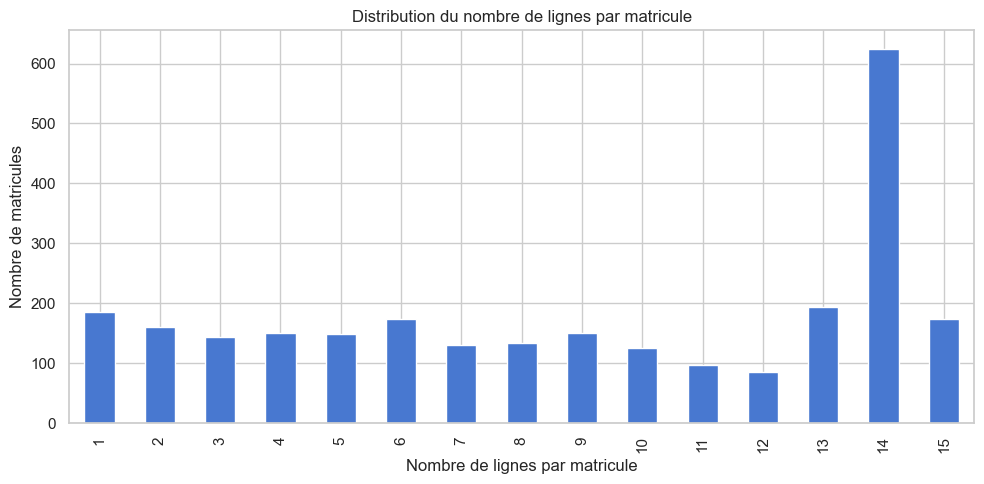

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
lines_per_matricule.value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title("Distribution du nombre de lignes par matricule")
ax.set_xlabel("Nombre de lignes par matricule")
ax.set_ylabel("Nombre de matricules")
plt.tight_layout()
plt.show()

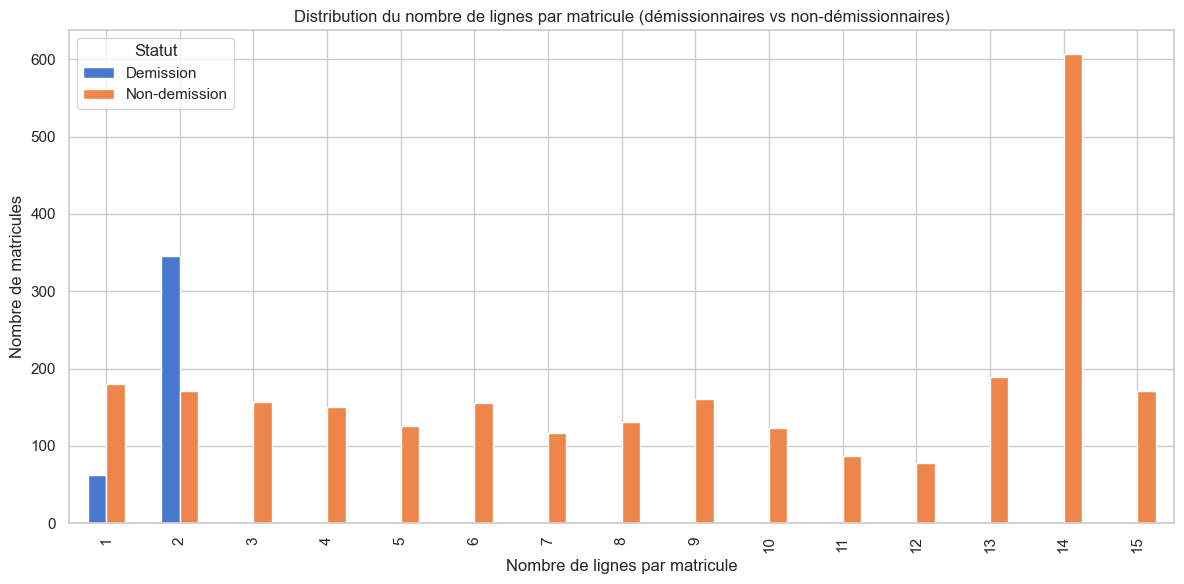

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

# Calcul pour les démissionnaires
lines_per_matricule_resigned = df[df[LABEL_COL]==1].groupby('matricule').size().value_counts().sort_index()

# Calcul pour les non-démissionnaires
lines_per_matricule_stayed = df[df[LABEL_COL]==0].groupby('matricule').size().value_counts().sort_index()

# Créer un DataFrame pour faciliter le plot côte à côte
comparison_df = pd.DataFrame({
    LABEL_NAMES[1]: lines_per_matricule_resigned,
    LABEL_NAMES[0]: lines_per_matricule_stayed
}).fillna(0)

comparison_df.plot(kind='bar', ax=ax, color=sns.color_palette("muted", 2))
ax.set_title("Distribution du nombre de lignes par matricule (démissionnaires vs non-démissionnaires)")
ax.set_xlabel("Nombre de lignes par matricule")
ax.set_ylabel("Nombre de matricules")
ax.legend(title="Statut")
plt.tight_layout()
plt.show()

Il y plusieurs lignes correspondant au même matricule dans notre jeu de données, pour avoir une analyse cohérente et pertinente nous faisons le choix d'aggréger le dataset par matricule et de ne garder que la ligne la plus récente pour analyser les distributions.

Il y a une nouvelle ligne tout les 3-4 mois, ce qui pourrait correspondre à un entretient trimestriel et les lignes supplémentaires à un évènmenent particulier comme une promotion ou un changement de service.

On observe également que les personnes démissionnaires n'ont que très peu de lignes en comparaison avec les personnes non-démissionnaires. Il est possible que les gérants de la base de données aient supprimé les lignes plus anciennes ou alors c'est un indicateur a prendre en compte pour les analyses.

In [47]:
df_aggregated = df.sort_values('Ancienneté groupe (années)').groupby('matricule').tail(1).reset_index(drop=True)

print(f"Avant agrégation : {len(df)} lignes, {df['matricule'].nunique()} matricules uniques")
print(f"Après agrégation : {len(df_aggregated)} lignes, {df_aggregated['matricule'].nunique()} matricules uniques")

Avant agrégation : 23857 lignes, 2676 matricules uniques
Après agrégation : 2676 lignes, 2676 matricules uniques


### 1.2 Desequilibre des classes

Repartition de la target:
  Classe 0 (Non-demission) : 2268 (84.75%)
  Classe 1 (Demission) : 408 (15.25%)


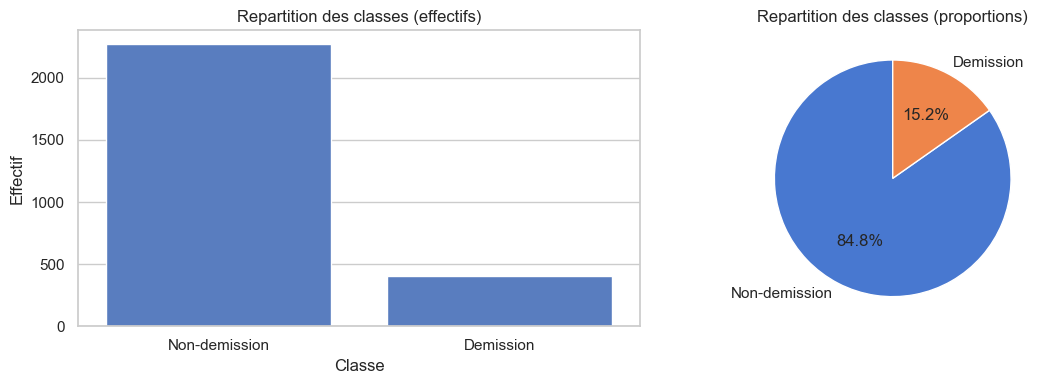

In [48]:
label_counts = df_aggregated[LABEL_COL].value_counts()
label_pct = df_aggregated[LABEL_COL].value_counts(normalize=True).mul(100).round(2)

print("Repartition de la target:")
for cls in label_counts.index:
    print(f"  Classe {cls} ({LABEL_NAMES[cls]}) : {label_counts[cls]} ({label_pct[cls]}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df_aggregated, x=LABEL_COL, ax=axes[0])
axes[0].set_title("Repartition des classes (effectifs)")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Effectif")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels([LABEL_NAMES[0], LABEL_NAMES[1]])

axes[1].pie(
    label_counts.values,
    labels=[LABEL_NAMES[k] for k in label_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("muted", 2),
)
axes[1].set_title("Repartition des classes (proportions)")

plt.tight_layout()
plt.show()

Le jeu de données est très déséquilibré: seulement 15.2% des employes ont demissionnées (408 personnes) contre 84.75% qui n'ont pas demissionné (2268).

On doit le prendre en compte pour la modélisation (sampling, class weight, metriques adaptees comme le F1-score ou l'AUC-ROC et éviter l'accuracy).

### 1.3 Exploration des variables categorielles

--- Famille d'emploi ---
  Nombre de modalites : 8
  Modalites : ['Production', 'Etudes & Technique', 'Support', 'IT', 'Commercial/Business', 'Développement Immobilier', 'Matériel/Equipement', 'Management']
  Taux de démission global : 15.2%



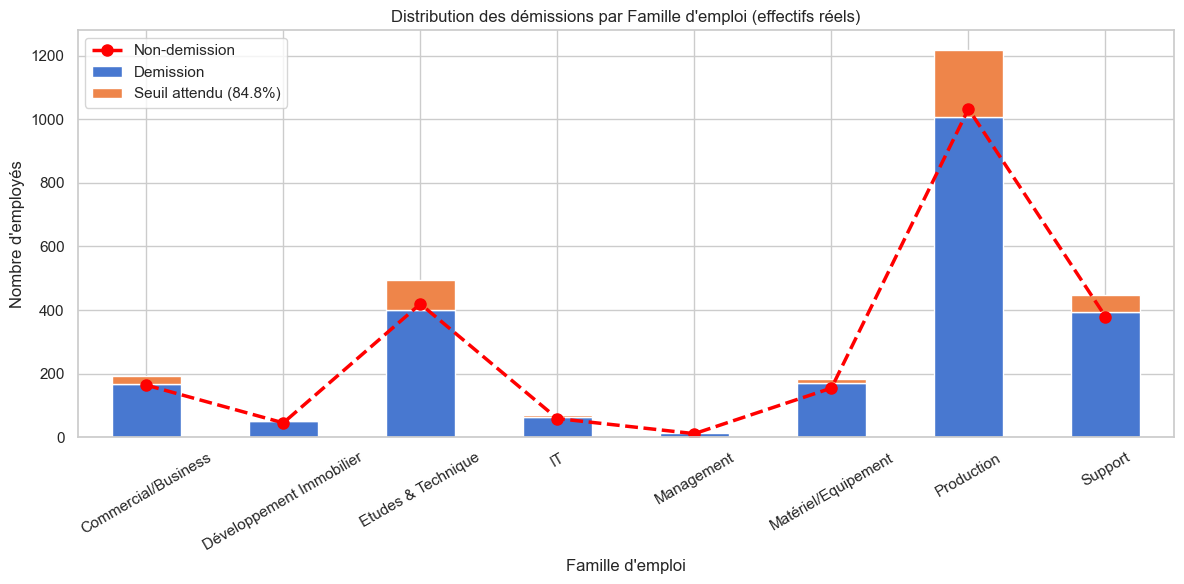

--- Statut marital ---
  Nombre de modalites : 9
  Modalites : ['PACS', 'Divorcé(e)', 'Célibataire', 'Marié(e)', 'Union libre', 'Concubin', 'Séparé(e)', 'ex PACS', 'Veuf(ve)']
  Taux de démission global : 15.2%



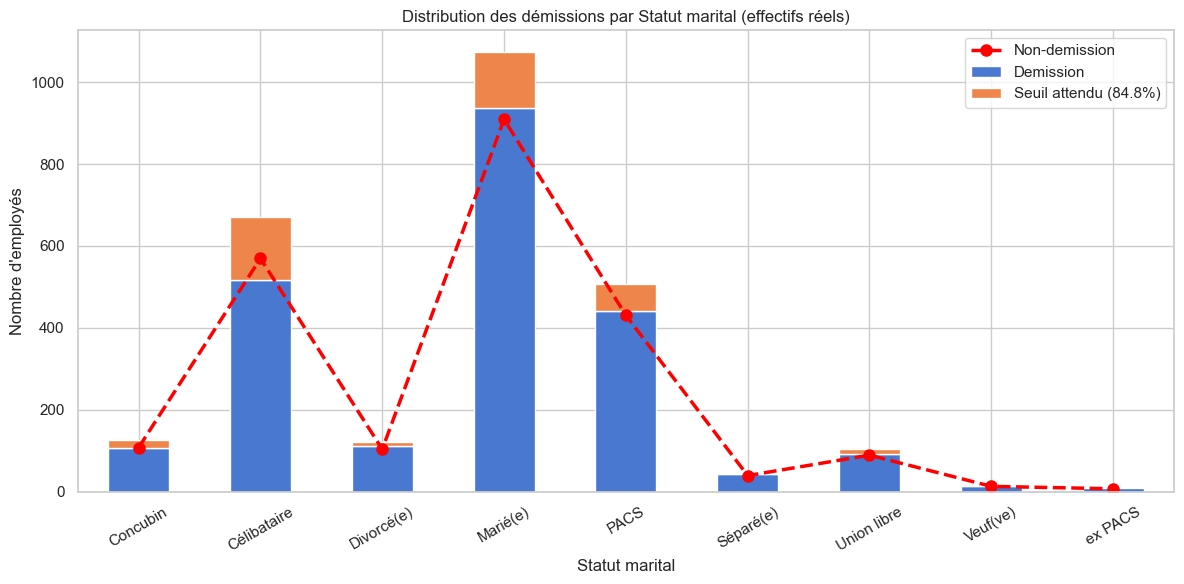

In [49]:
categorical_columns = ["Famille d'emploi", "Statut marital"]

# Calculer le taux global de démission pour référence
global_resignation_rate = 1 - (df_aggregated[LABEL_COL].sum() / len(df_aggregated))

for col in categorical_columns:
    print(f"--- {col} ---")
    print(f"  Nombre de modalites : {df_aggregated[col].nunique()}")
    print(f"  Modalites : {df_aggregated[col].unique().tolist()}")
    print(f"  Taux de démission global : {(1-global_resignation_rate)*100:.1f}%")
    print()

    # Créer un crosstab avec effectifs RÉELS (sans normalize)
    crosstab = pd.crosstab(df_aggregated[col], df_aggregated[LABEL_COL])
    
    fig, ax = plt.subplots(figsize=(12, 6))
    crosstab.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=sns.color_palette("muted", 2),
    )
    
    # Calculer la courbe de référence : 15.2% * effectif par modalité
    effectif_par_modalite = crosstab.sum(axis=1)
    seuil_reference = effectif_par_modalite * global_resignation_rate
    
    # Ajouter la courbe de référence
    ax.plot(
        range(len(effectif_par_modalite)),
        seuil_reference.values,
        color='red',
        linestyle='--',
        linewidth=2.5,
        marker='o',
        markersize=8,
        label=f'Seuil attendu ({global_resignation_rate*100:.1f}% des effectifs)'
    )
    
    ax.set_title(f"Distribution des démissions par {col} (effectifs réels)")
    ax.set_xlabel(col)
    ax.set_ylabel("Nombre d'employés")
    ax.legend([LABEL_NAMES[0], LABEL_NAMES[1], f'Seuil attendu ({global_resignation_rate*100:.1f}%)'])
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

Le concubinage et union libre nous semble être la même chose. Il faudra si c'est confirmé les regrouper dans la même catégorie.

- **Famille d'emploi** : La famille Production est de loin la plus representee, suivie de Etudes & Technique et Support. Management est tres minoritaire (132). Cette repartition reflete une structure industrielle classique.
- **Statut marital** : Les Marie(e)s representent la plus grande part, suivis des Célibataires et des PACS. Les statuts Veuf(ve) et ex PACS sont rares.

### 1.4 Exploration des variables numeriques

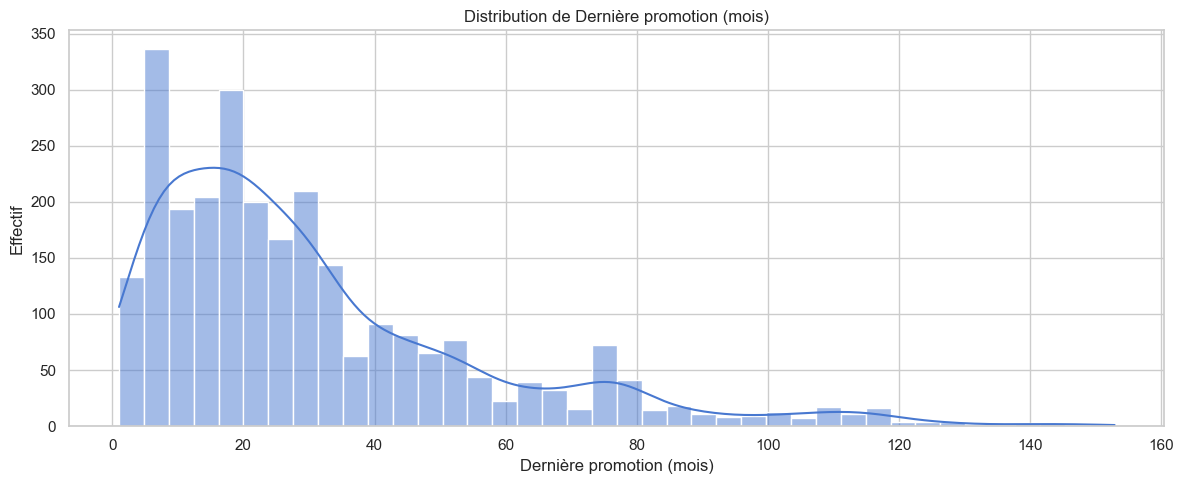

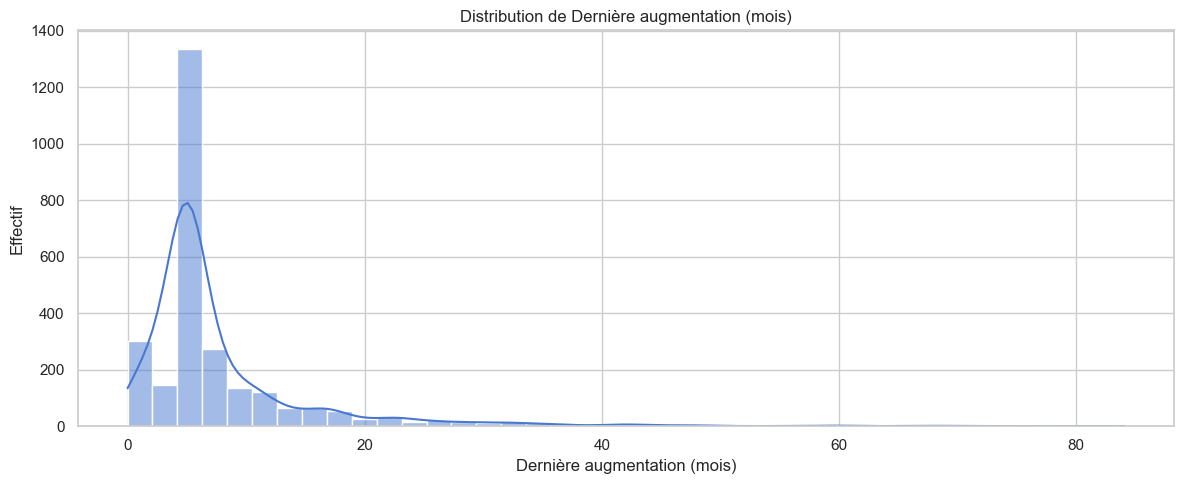

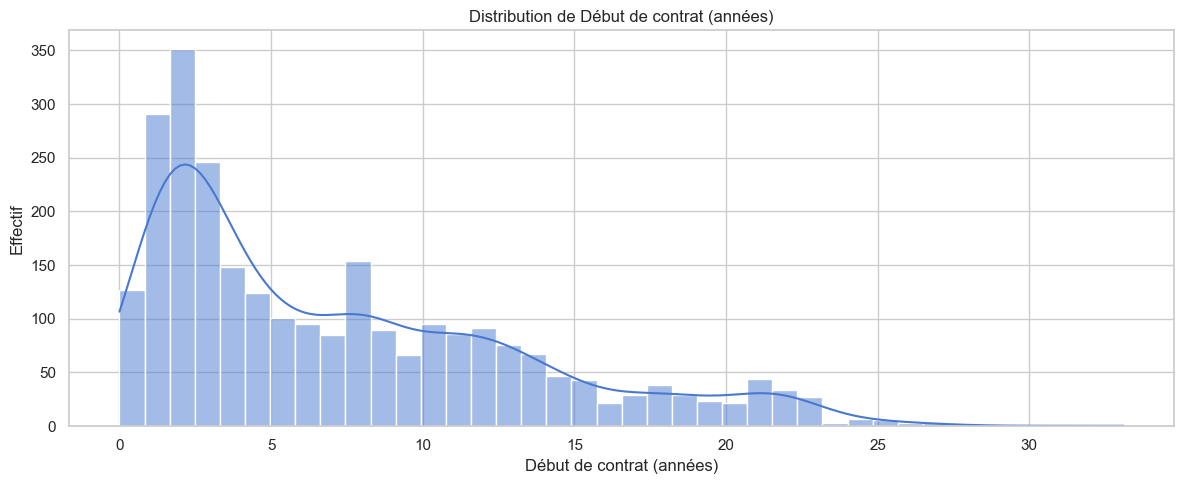

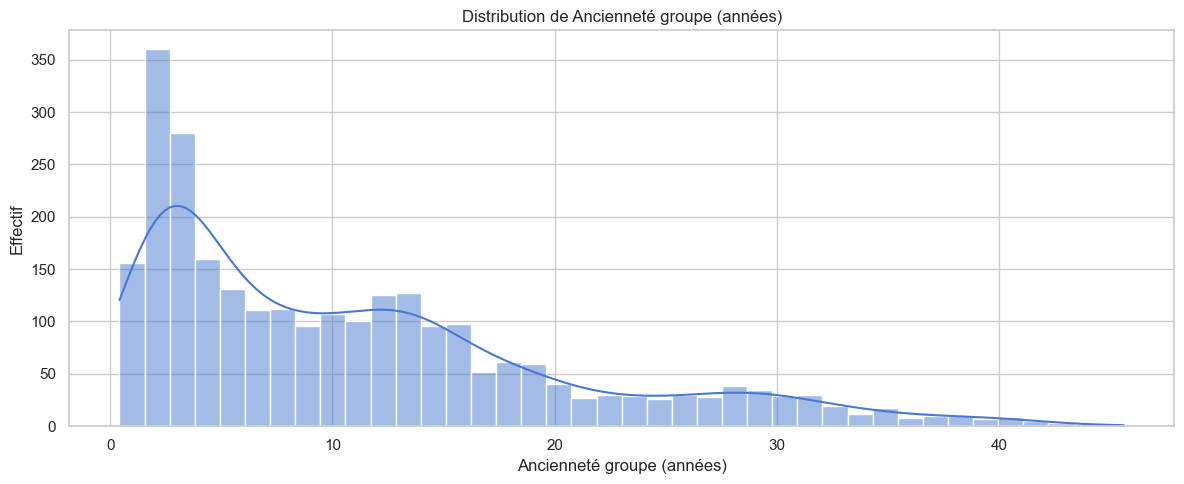

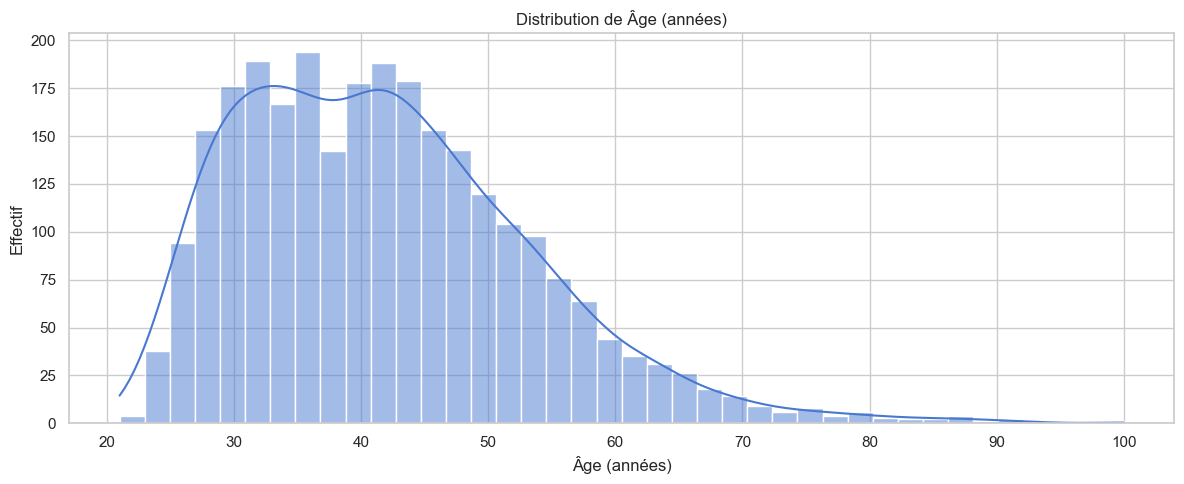

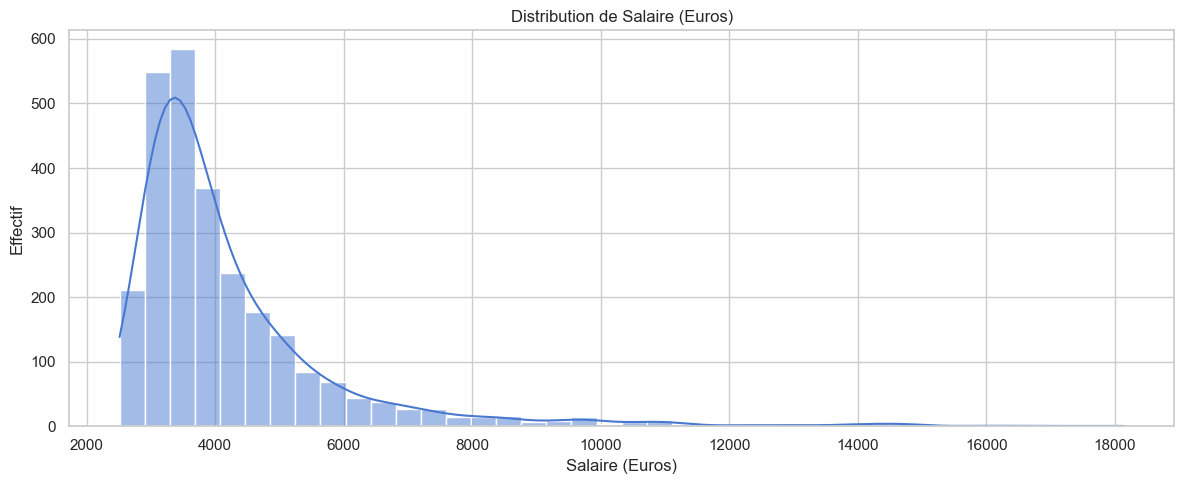

In [50]:
numerical_columns = [
    "Dernière promotion (mois)",
    "Dernière augmentation (mois)",
    "Début de contrat (années)",
    "Ancienneté groupe (années)",
    "Âge (années)",
    "Salaire (Euros)",
]

for col in numerical_columns:
    plot_distribution(
        data=df_aggregated,
        column=col,
        title=f"Distribution de {col}",
        bins=40,
    )

--- Parent ---
  Valeurs uniques : [0, 1]
  Repartition :
Parent
0     884
1    1792



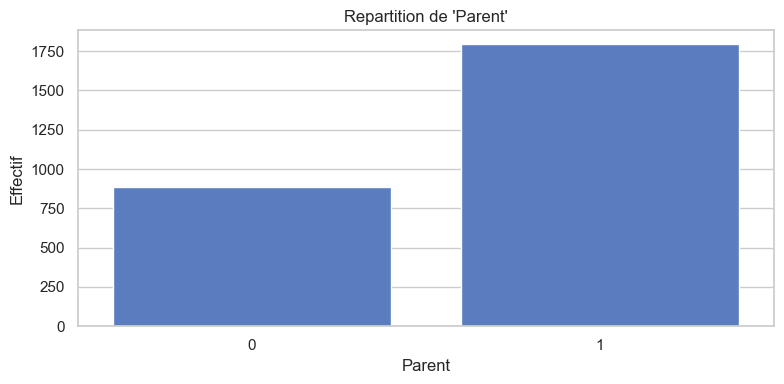

--- Niveau hiérarchique ---
  Valeurs uniques : [1, 2, 3, 4]
  Repartition :
Niveau hiérarchique
1    1386
2    1044
3     243
4       3



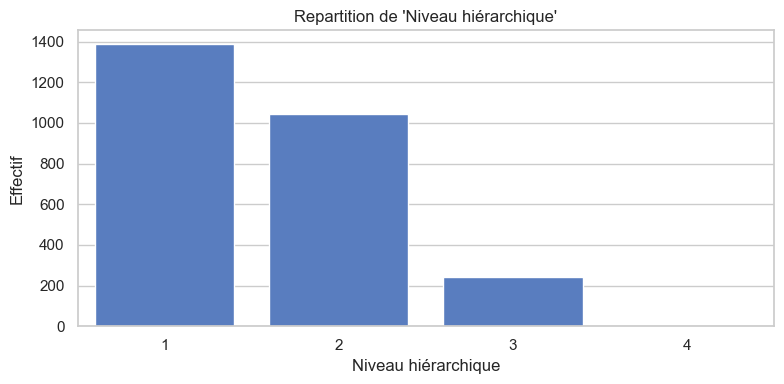

--- Véhicule ---
  Valeurs uniques : [0, 1, 2]
  Repartition :
Véhicule
0    1274
1    1401
2       1



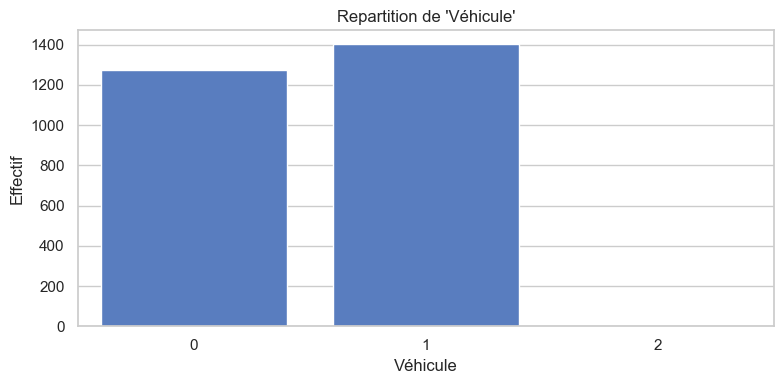

--- Etablissement ---
  Valeurs uniques : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 33, 34, 35, 36]
  Repartition :
Etablissement
0      11
1      61
2      61
3      33
4      43
5      24
6      99
7      74
8      63
9      71
10     32
11     82
12     63
13     32
14     16
15     38
16     43
17     33
18     25
19     48
20     30
21     52
22     49
23     45
24    182
25     40
26     73
27    235
28    960
29     51
30      3
33      1
34      1
35      1
36      1



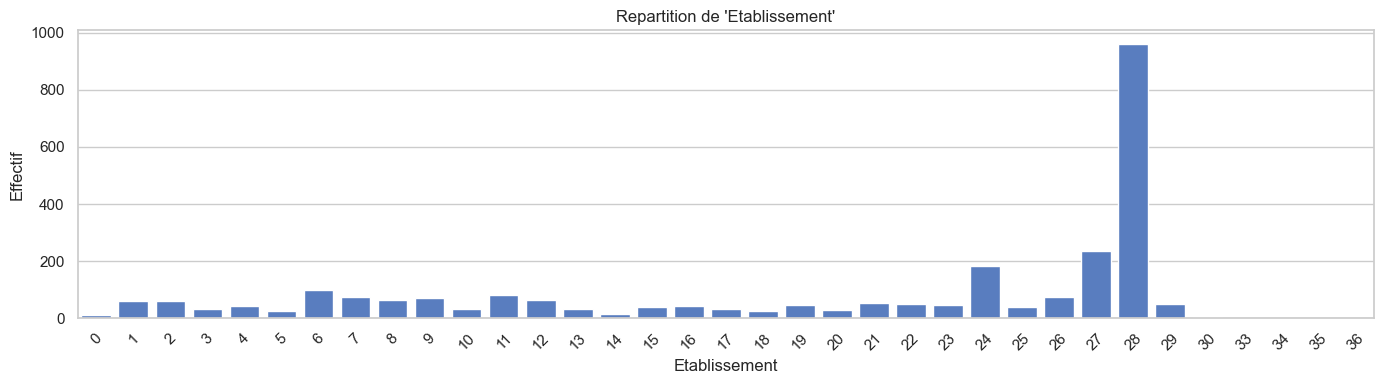

In [51]:
discrete_columns = ["Parent", "Niveau hiérarchique", "Véhicule", "Etablissement"]

for col in discrete_columns:
    print(f"--- {col} ---")
    print(f"  Valeurs uniques : {sorted(df_aggregated[col].unique())}")
    print(f"  Repartition :")
    print(df_aggregated[col].value_counts().sort_index().to_string())
    print()

    plot_countplot(
        data=df_aggregated,
        column=col,
        title=f"Repartition de '{col}'",
        rotate_labels=45 if col == "Etablissement" else 0,
        figsize=(14, 4) if col == "Etablissement" else (8, 4),
    )

**Commentaire sur les variables numeriques :**

- **Derniere promotion (mois)** : Distribution etalee a droite. La plupart des promotions ont eu lieu recemment.
- **Derniere augmentation (mois)** : Concentree entre 0 et 25 mois, avec une moyenne a ~7 mois.
- **Debut de contrat (annees)** : Distribution etalee, de 0 (embauche recente) a 33 ans. Mediane ~6 ans.
- **Anciennete groupe (annees)** : Similaire mais avec des valeurs plus elevees, ce qui est coherent car l'anciennete groupe inclut les eventuelles mobilites.
- **Age (annees)** : De 20 a 100 ans (des valeurs > 65 ans sont potentiellement aberrantes ou concernent des cas particuliers). Mediane ~40 ans.
- **Salaire (Euros)** : De 2 134 a 18 137 euros. Distribution concentree entre 2 500 et 5 000 euros avec une longue queue a droite.
- **Parent** : Variable binaire (0/1), la majorité est parent.
- **Niveau hierarchique** : 4 niveaux, le niveau 1 est le plus represente (~60%).
- **Vehicule** : Essentiellement binaire (0/1), 4 valeurs a 2 (possiblement atypiques).
- **Etablissement** : 35 etablissements distincts, avec des effectifs variables.

### 1.5 Parcours type : employe demissionnaire vs non-demissionnaire

On selectionne un employe ayant demissionne et un employe ne l'ayant pas fait, puis on compare leurs profils cote a cote.

In [52]:
# Selection d'un employe par classe (le premier de chaque groupe)
employee_resigned = df[df[LABEL_COL] == 1].iloc[0]
employee_stayed = df[df[LABEL_COL] == 0].iloc[0]

comparison = pd.DataFrame({
    "Demissionnaire": employee_resigned,
    "Non-demissionnaire": employee_stayed,
})

print("Comparaison de deux profils individuels :")
comparison

Comparaison de deux profils individuels :


,Demissionnaire,Non-demissionnaire
Famille d'emploi,Production,Production
Dernière promotion (mois),5.24,8.51
Dernière augmentation (mois),5.1,7.9
Début de contrat (années),1.02,0.91
Ancienneté groupe (années),1.75,0.97
Etablissement,27,27
Âge (années),24,30
Parent,0,1
Niveau hiérarchique,1,1
Salaire (Euros),2641,3199


Regardons l'historique des deux profils vu précédemment:

In [53]:
df[df.matricule==employee_resigned.matricule]

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
3,Production,5.24,5.10,1.02,1.75,27,24,0,1,2641,Célibataire,0,2619,1
439,Production,7.99,7.86,1.29,1.92,27,25,0,1,2640,Célibataire,0,2619,1


In [54]:
df[df.matricule==employee_stayed.matricule]

,Famille d'emploi,Dernière promotion (mois),Dernière augmentation (mois),Début de contrat (années),Ancienneté groupe (années),Etablissement,Âge (années),Parent,Niveau hiérarchique,Salaire (Euros),Statut marital,Véhicule,matricule,label
0,Production,8.510000,7.900000,0.91,0.97,27,30,1,1,3199,Marié(e),0,32,0
435,Production,11.280000,10.750000,1.18,1.20,27,30,1,1,3200,Marié(e),0,32,0
1735,Production,14.040000,13.590000,1.45,1.45,27,31,1,1,3200,Marié(e),0,32,0
3247,Production,16.920000,16.370001,1.70,1.70,27,32,1,1,3199,Marié(e),0,32,0
4799,Production,19.889999,19.340000,2.08,2.08,28,33,1,1,3199,Marié(e),0,32,0
6358,Etudes & Technique,2.350000,21.889999,2.27,2.38,27,34,1,1,3202,Marié(e),0,32,0
7967,Etudes & Technique,5.960000,0.960000,2.53,2.53,27,34,1,1,3560,Marié(e),0,32,0
9637,Etudes & Technique,8.710000,3.890000,2.77,2.77,27,34,1,1,3559,Marié(e),0,32,0
11353,Etudes & Technique,11.500000,6.770000,3.03,3.03,27,34,1,1,3560,Marié(e),0,32,0
13091,Etudes & Technique,14.770000,1.980000,3.25,3.31,27,35,1,1,3773,Marié(e),0,32,0


In [55]:
# Comparaison des moyennes par classe (profil statistique moyen)
columns_for_comparison = [c for c in df_aggregated.columns if c not in ["matricule", LABEL_COL]]

mean_by_label = df_aggregated.groupby(LABEL_COL)[numerical_columns+discrete_columns].mean().round(2).T
mean_by_label.columns = [LABEL_NAMES[c] for c in mean_by_label.columns]

print("Moyennes des variables numeriques par classe :")
mean_by_label

Moyennes des variables numeriques par classe :


,Non-demission,Demission
Dernière promotion (mois),32.10,24.53
Dernière augmentation (mois),7.57,8.19
Début de contrat (années),7.73,4.78
Ancienneté groupe (années),11.98,6.34
Âge (années),42.91,35.42
Salaire (Euros),4325.11,3634.56
Parent,0.70,0.49
Niveau hiérarchique,1.62,1.35
Véhicule,0.56,0.32
Etablissement,20.64,19.18


En comparant les profils individuels et les moyennes par classe, plusieurs tendances se dessinent :
- Les employes demissionnaires tendent a etre plus jeunes, avec une anciennete et un debut de contrat plus recents.
- Leur salaire moyen est plus faible, ce qui est coherent avec une anciennete moindre.
- Ils semblent avoir un niveau hierarchique plus bas (souvent niveau 1).
- Les delais depuis la derniere promotion et augmentation ne montrent pas de difference flagrante a premiere vue, mais cela devra etre confirme statistiquement. Il semble que les personnes qui démissionnent ont eu une promotion plus récemment mais non suivie d'une augmentation.
- La majorité des personnes ayant démissionné n'ont pas d'enfants (51%)
- La plupart des personnes ayant démissionné sont plus bas dans la hiérarchie en moyenne.

Ces observations sont coherentes avec l'intuition : les employes en debut de carriere, moins bien remuneres et a faible niveau hierarchique, ont un risque de demission plus eleve.

In [56]:
columns_for_comparison = [c for c in df_aggregated.columns if c not in ["matricule", LABEL_COL]]

mean_by_label = df_aggregated.groupby(LABEL_COL)[numerical_columns+discrete_columns].mean().round(2).T
mean_by_label.columns = [LABEL_NAMES[c] for c in mean_by_label.columns]

median_by_label = df_aggregated.groupby(LABEL_COL)[numerical_columns+discrete_columns].median().round(2).T
median_by_label.columns = [LABEL_NAMES[c] for c in median_by_label.columns]

std_by_label = df_aggregated.groupby(LABEL_COL)[numerical_columns+discrete_columns].std().round(2).T
std_by_label.columns = [LABEL_NAMES[c] for c in std_by_label.columns]

print("Moyennes des variables numeriques par classe :")
print(mean_by_label)
print("\nMédianes des variables numeriques par classe :")
print(median_by_label)
print("\nÉcarts-types des variables numeriques par classe :")
print(std_by_label)

Moyennes des variables numeriques par classe :
                              Non-demission  Demission
Dernière promotion (mois)             32.10      24.53
Dernière augmentation (mois)           7.57       8.19
Début de contrat (années)              7.73       4.78
Ancienneté groupe (années)            11.98       6.34
Âge (années)                          42.91      35.42
Salaire (Euros)                     4325.11    3634.56
Parent                                 0.70       0.49
Niveau hiérarchique                    1.62       1.35
Véhicule                               0.56       0.32
Etablissement                         20.64      19.18

Médianes des variables numeriques par classe :
                              Non-demission  Demission
Dernière promotion (mois)             24.16      20.17
Dernière augmentation (mois)           5.00       7.34
Début de contrat (années)              6.12       3.25
Ancienneté groupe (années)            10.04       4.70
Âge (années)             

### 1.6 Matrice de correlation

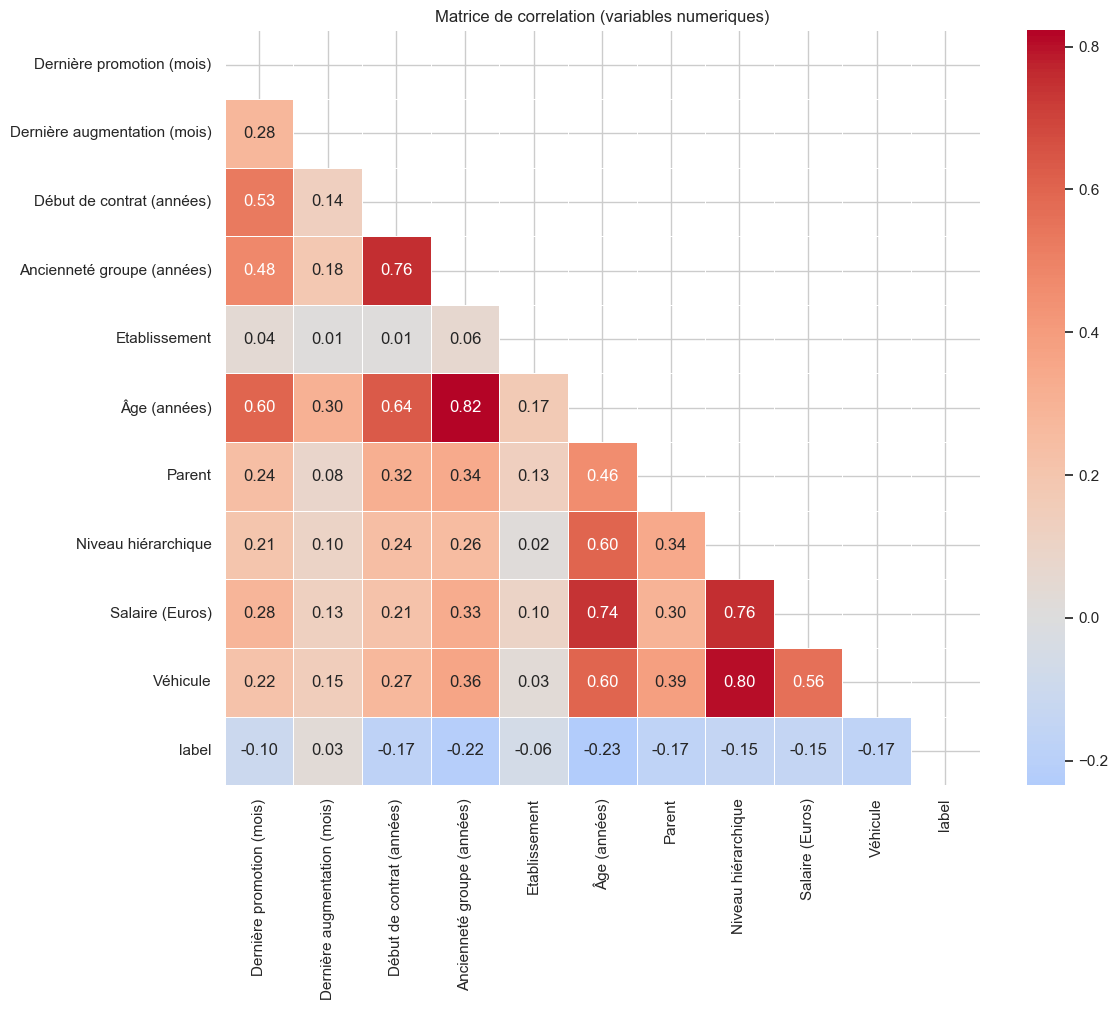

In [57]:
columns_for_correlation = [
    c for c in df_aggregated.select_dtypes(include="number").columns
    if c != "matricule"
]

correlation_matrix = df_aggregated[columns_for_correlation].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matrice de correlation (variables numeriques)")
plt.tight_layout()
plt.show()

**Commentaire sur la matrice de correlation :**

Correlations notables :
- **Debut de contrat / Anciennete groupe** : Forte correlation positive attendue -- plus le contrat est ancien, plus l'anciennete dans le groupe est elevee.
- **Age / Anciennete groupe** et **Age / Debut de contrat** : Correlations positives moderees -- les employes plus ages ont logiquement plus d'anciennete.
- **Salaire / Niveau hierarchique** : Correlation positive -- un niveau hierarchique eleve s'accompagne d'un salaire plus eleve.
- **Salaire / Age** et **Salaire / Anciennete** : Correlations positives moderees -- la remuneration augmente avec l'experience.
- **Vehicule / Niveau hierarchique** et **Vehicule / Salaire** : Correlations positives -- l'attribution d'un vehicule est liee au niveau et au salaire.

Correlations avec la variable cible (`label`) :
- Les correlations avec `label` sont globalement **faibles**, ce qui est attendu pour un evenement rare (~3%). Les plus marquees concernent probablement l'age, l'anciennete et le salaire (negatives : les plus jeunes/moins anciens/moins bien payes demissionnent davantage).

### 1.7 Analyses complementaires : distributions par classe

On compare les distributions des variables numeriques entre les employes demissionnaires et non-demissionnaires pour identifier visuellement les variables discriminantes.

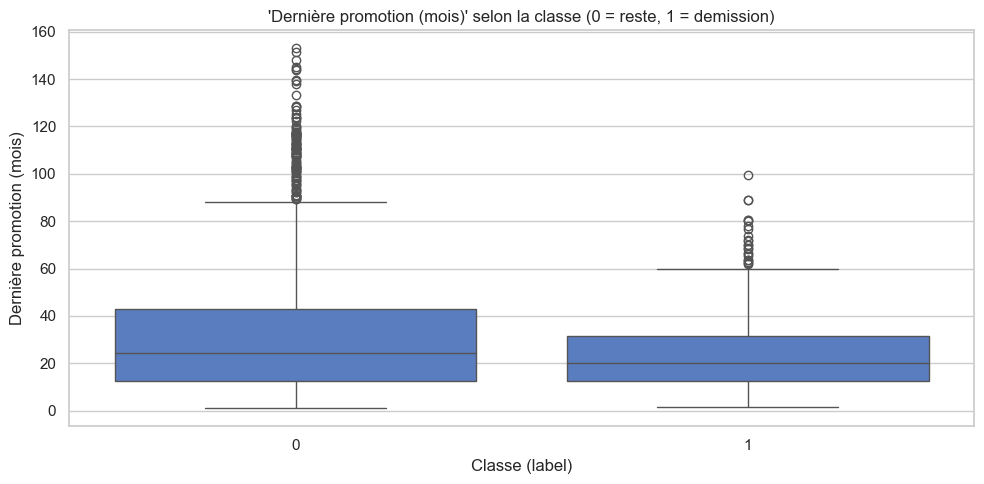

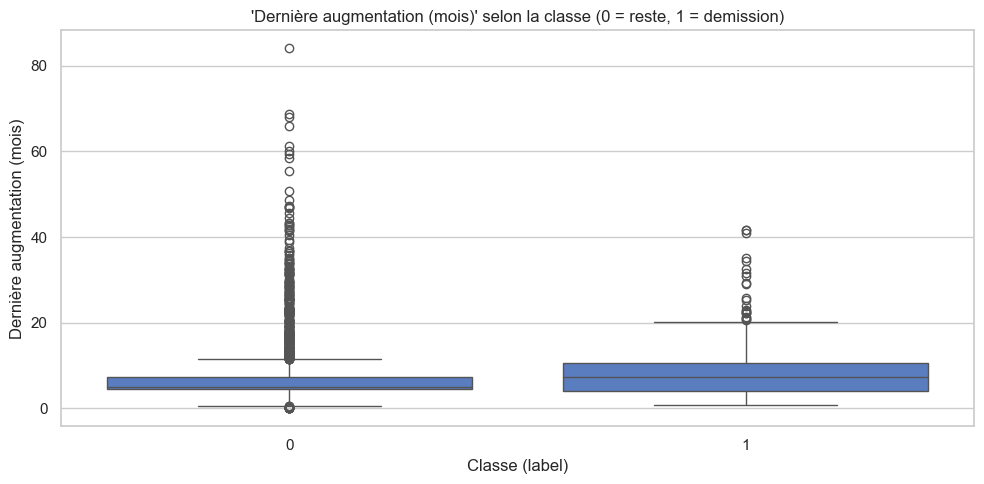

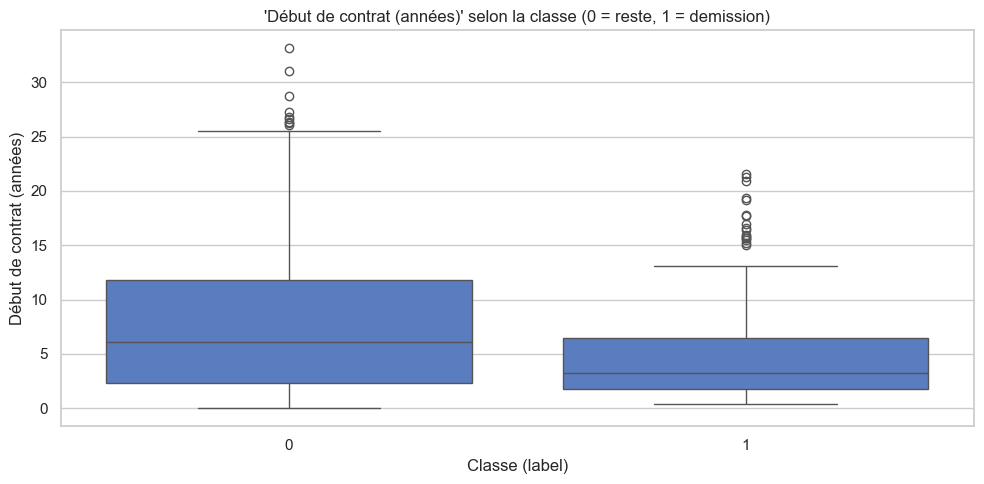

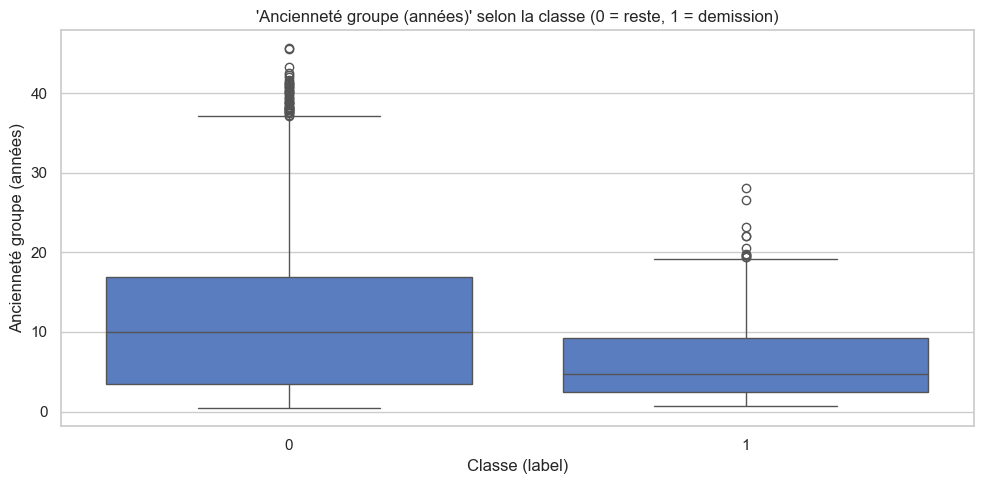

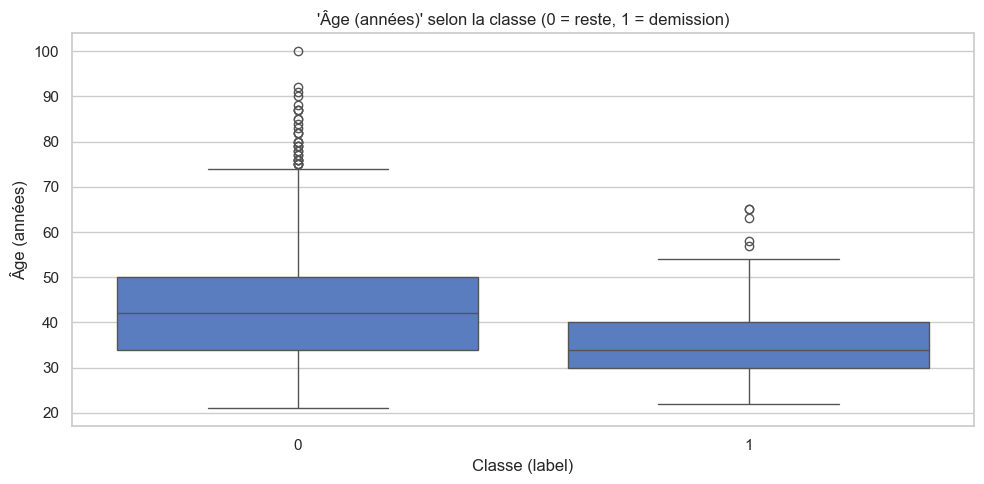

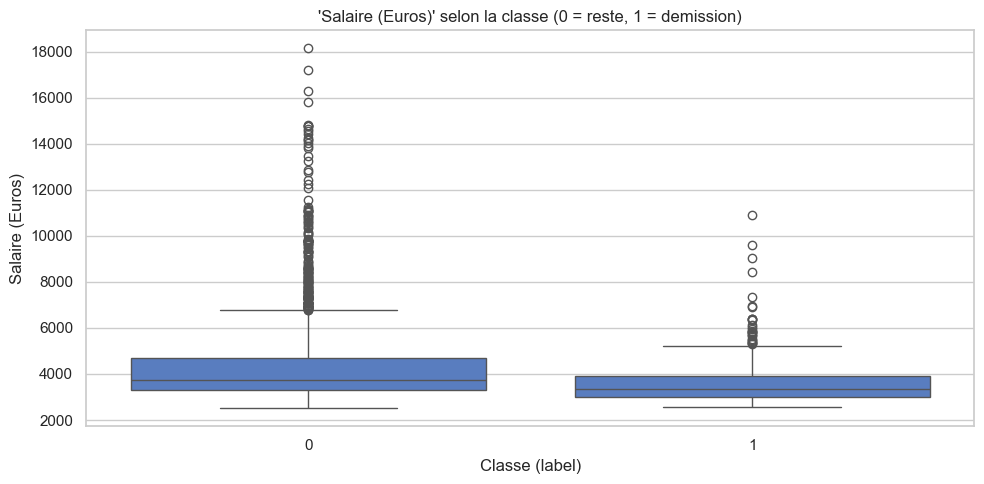

In [58]:
# Boxplots compares par classe pour chaque variable numerique continue
for col in numerical_columns:
    plot_boxplot_by_label(
        data=df_aggregated,
        column=col,
        title=f"'{col}' selon la classe (0 = reste, 1 = demission)",
    )

In [59]:
# Taux de demission par variable categorielle
def compute_resignation_rate(
    data: pd.DataFrame,
    group_col: str,
    label_col: str = LABEL_COL,
) -> pd.DataFrame:
    """Calcule le taux de demission par modalite d'une variable categorielle."""
    rates = (
        data.groupby(group_col)[label_col]
        .agg(["sum", "count"])
        .rename(columns={"sum": "nb_demissions", "count": "effectif_total"})
    )
    rates["taux_demission_%"] = (rates["nb_demissions"] / rates["effectif_total"] * 100).round(2)
    return rates.sort_values("taux_demission_%", ascending=False)


for col in categorical_columns + ["Niveau hiérarchique", "Parent"]:
    print(f"--- Taux de demission par '{col}' ---")
    rates = compute_resignation_rate(df_aggregated, col)
    display(rates)
    print()

--- Taux de demission par 'Famille d'emploi' ---


,nb_demissions,effectif_total,taux_demission_%
Famille d'emploi,,,
Etudes & Technique,96,495,19.39
Production,210,1218,17.24
Commercial/Business,26,194,13.40
Support,55,448,12.28
IT,7,70,10.00
Matériel/Equipement,13,183,7.10
Développement Immobilier,1,54,1.85
Management,0,14,0.00



--- Taux de demission par 'Statut marital' ---


,nb_demissions,effectif_total,taux_demission_%
Statut marital,,,
Célibataire,155,672,23.07
Concubin,20,127,15.75
Union libre,14,105,13.33
PACS,67,508,13.19
Marié(e),137,1073,12.77
Séparé(e),4,46,8.70
Divorcé(e),10,122,8.20
Veuf(ve),1,15,6.67
ex PACS,0,8,0.00



--- Taux de demission par 'Niveau hiérarchique' ---


,nb_demissions,effectif_total,taux_demission_%
Niveau hiérarchique,,,
1,279,1386,20.13
2,116,1044,11.11
3,13,243,5.35
4,0,3,0.00



--- Taux de demission par 'Parent' ---


,nb_demissions,effectif_total,taux_demission_%
Parent,,,
0,210,884,23.76
1,198,1792,11.05


**Commentaire sur les analyses complementaires :**

Les boxplots confirment les tendances observees :
- Les **demissionnaires sont en moyenne plus jeunes**, avec moins d'anciennete et un salaire plus faible.
- Le **debut de contrat** est plus recent pour les demissionnaires, ce qui est coherent avec une moindre integration dans l'entreprise.
- Les variables de temps depuis derniere promotion/augmentation ne montrent pas de separation nette.

Les taux de demission par variable categorielle revelent :
- Des disparites possibles entre familles d'emploi (certains metiers plus touches que d'autres).
- Le niveau hierarchique 1 concentre probablement un taux de demission plus eleve.
- Les non-parents pourraient avoir un taux de demission plus eleve (moins d'attaches familiales).

---
## 2. Analyse des variables sensibles et biais potentiels

Dans le contexte de l'IA responsable, certaines variables peuvent introduire des biais discriminatoires dans un modele predictif. On distingue :
- Les **variables sensibles directes** : elles correspondent a des caracteristiques protegees par la loi (sexe, origine ethnique, religion, orientation sexuelle, handicap, etc.).
- Les **variables proxies** : elles ne sont pas sensibles en elles-memes mais permettent d'inferer, directement ou indirectement, une caracteristique sensible.

### 2.1 Identification des variables sensibles

In [60]:
# Classification des variables selon leur sensibilite
variable_sensitivity = pd.DataFrame({
    "Variable": [
        "Age (annees)",
        "Statut marital",
        "Parent",
        "Salaire (Euros)",
        "Niveau hierarchique",
        "Vehicule",
        "Etablissement",
        "Famille d'emploi",
        "Derniere promotion (mois)",
        "Derniere augmentation (mois)",
        "Debut de contrat (annees)",
        "Anciennete groupe (annees)",
        "matricule",
    ],
    "Classification": [
        "Sensible directe",
        "Sensible directe",
        "Proxy",
        "Proxy",
        "Proxy",
        "Proxy",
        "Proxy potentiel",
        "Non sensible",
        "Non sensible",
        "Non sensible",
        "Non sensible",
        "Non sensible",
        "Identifiant (a exclure)",
    ],
    "Justification": [
        "L'age est un critere protege par la loi (discrimination liee a l'age). "
        "Un modele qui utilise l'age pourrait defavoriser les seniors ou les jeunes.",

        "Le statut marital peut reveler indirectement la situation familiale, "
        "l'orientation sexuelle (ex. PACS historiquement associe aux couples de meme sexe), "
        "ou le sexe (veuf/veuve). C'est un critere protege.",

        "La variable Parent (0/1) est un proxy du sexe : les femmes etant statistiquement "
        "plus impactees par la parentalite (conge maternite, temps partiel), cette variable "
        "peut permettre d'inferer le sexe et introduire un biais de genre.",

        "Le salaire est fortement correle au niveau hierarchique, a l'age et a l'anciennete. "
        "Il peut etre un proxy indirect de l'age (discrimination) et reflete potentiellement "
        "des inegalites salariales preexistantes (genre, origine).",

        "Le niveau hierarchique est correle au salaire et a l'age. Il peut etre un proxy "
        "de l'age et reflete potentiellement des plafonds de verre (genre, origine).",

        "L'attribution d'un vehicule de fonction depend du niveau hierarchique et du salaire. "
        "En tant que proxy de ces variables, il herite de leurs biais potentiels.",

        "Le code d'etablissement pourrait etre un proxy geographique, et donc potentiellement "
        "correle a l'origine ethnique ou au niveau socio-economique d'une zone.",

        "Variable liee a la gestion de carriere, non sensible a priori.",
        "Variable liee a la gestion de carriere, non sensible a priori.",
        "Variable liee a la gestion de carriere, non sensible a priori.",
        "Duree depuis l'embauche, variable professionnelle neutre.",
        "Duree d'anciennete dans le groupe, variable professionnelle neutre.",
        "Simple identifiant, aucun pouvoir predictif ni sensibilite. Il peut y a plusieurs lignes de matricules dans le dataset. Il ne faut pas les supprimer pour garder l'historique des employés.",
    ],
})

variable_sensitivity.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
)

,Variable,Classification,Justification
0,Age (annees),Sensible directe,L'age est un critere protege par la loi (discrimination liee a l'age). Un modele qui utilise l'age pourrait defavoriser les seniors ou les jeunes.
1,Statut marital,Sensible directe,"Le statut marital peut reveler indirectement la situation familiale, l'orientation sexuelle (ex. PACS historiquement associe aux couples de meme sexe), ou le sexe (veuf/veuve). C'est un critere protege."
2,Parent,Proxy,"La variable Parent (0/1) est un proxy du sexe : les femmes etant statistiquement plus impactees par la parentalite (conge maternite, temps partiel), cette variable peut permettre d'inferer le sexe et introduire un biais de genre."
3,Salaire (Euros),Proxy,"Le salaire est fortement correle au niveau hierarchique, a l'age et a l'anciennete. Il peut etre un proxy indirect de l'age (discrimination) et reflete potentiellement des inegalites salariales preexistantes (genre, origine)."
4,Niveau hierarchique,Proxy,"Le niveau hierarchique est correle au salaire et a l'age. Il peut etre un proxy de l'age et reflete potentiellement des plafonds de verre (genre, origine)."
5,Vehicule,Proxy,"L'attribution d'un vehicule de fonction depend du niveau hierarchique et du salaire. En tant que proxy de ces variables, il herite de leurs biais potentiels."
6,Etablissement,Proxy potentiel,"Le code d'etablissement pourrait etre un proxy geographique, et donc potentiellement correle a l'origine ethnique ou au niveau socio-economique d'une zone."
7,Famille d'emploi,Non sensible,"Variable liee a la gestion de carriere, non sensible a priori."
8,Derniere promotion (mois),Non sensible,"Variable liee a la gestion de carriere, non sensible a priori."
9,Derniere augmentation (mois),Non sensible,"Variable liee a la gestion de carriere, non sensible a priori."


### 2.2 Analyse approfondie des variables sensibles

#### Age

L'age est un critere protege. Analysons sa distribution par classe pour detecter un eventuel biais.

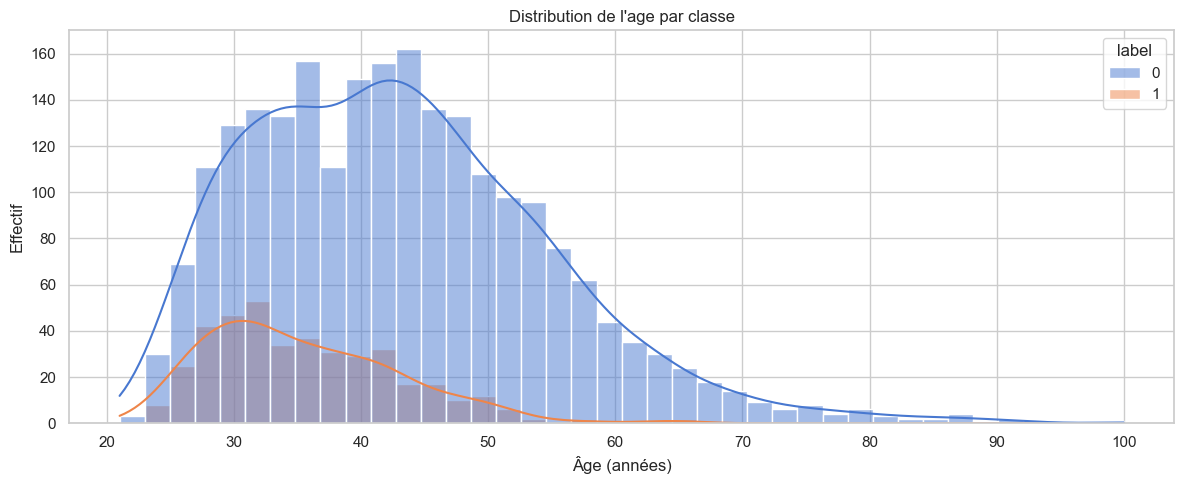

Taux de demission par tranche d'age :


C:\Users\zcb\AppData\Local\Temp\ipykernel_9884\3725120382.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(group_col)[label_col]


,nb_demissions,effectif_total,taux_demission_%
tranche_age,,,
25-29,92,335,27.46
30-34,109,444,24.55
20-24,9,42,21.43
35-39,84,425,19.76
40-44,62,456,13.60
45-49,32,357,8.96
50-54,15,261,5.75
60+,3,190,1.58
55-59,2,165,1.21


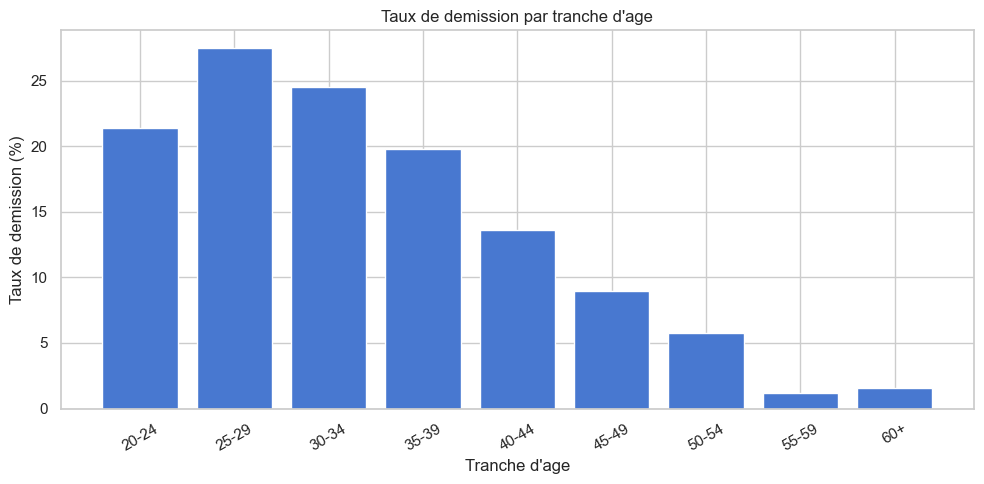

In [61]:
# Distribution de l'age par classe
plot_distribution(
    data=df_aggregated,
    column="Âge (années)",
    title="Distribution de l'age par classe",
    hue=LABEL_COL,
    bins=40,
)

# Tranches d'age pour une analyse plus fine
age_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
age_labels = ["20-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60+"]
df_aggregated["tranche_age"] = pd.cut(df_aggregated["Âge (années)"], bins=age_bins, labels=age_labels, right=False)

rates_age = compute_resignation_rate(df_aggregated, "tranche_age")
print("Taux de demission par tranche d'age :")
display(rates_age)

fig, ax = plt.subplots(figsize=(10, 5))
rates_age_sorted = rates_age.sort_index()
ax.bar(rates_age_sorted.index.astype(str), rates_age_sorted["taux_demission_%"])
ax.set_title("Taux de demission par tranche d'age")
ax.set_xlabel("Tranche d'age")
ax.set_ylabel("Taux de demission (%)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Le taux de demission est nettement plus eleve chez les jeunes employes (20-29 ans), ce qui confirme que l'age est un facteur discriminant. Un modele entraine sur ces donnees risquerait de predire plus souvent la demission pour les jeunes, ce qui pourrait mener a des decisions RH biaisees (par ex. ne pas investir dans la formation des jeunes recrues).

#### Statut marital

Taux de demission par statut marital :


,nb_demissions,effectif_total,taux_demission_%
Statut marital,,,
Célibataire,155,672,23.07
Concubin,20,127,15.75
Union libre,14,105,13.33
PACS,67,508,13.19
Marié(e),137,1073,12.77
Séparé(e),4,46,8.70
Divorcé(e),10,122,8.20
Veuf(ve),1,15,6.67
ex PACS,0,8,0.00


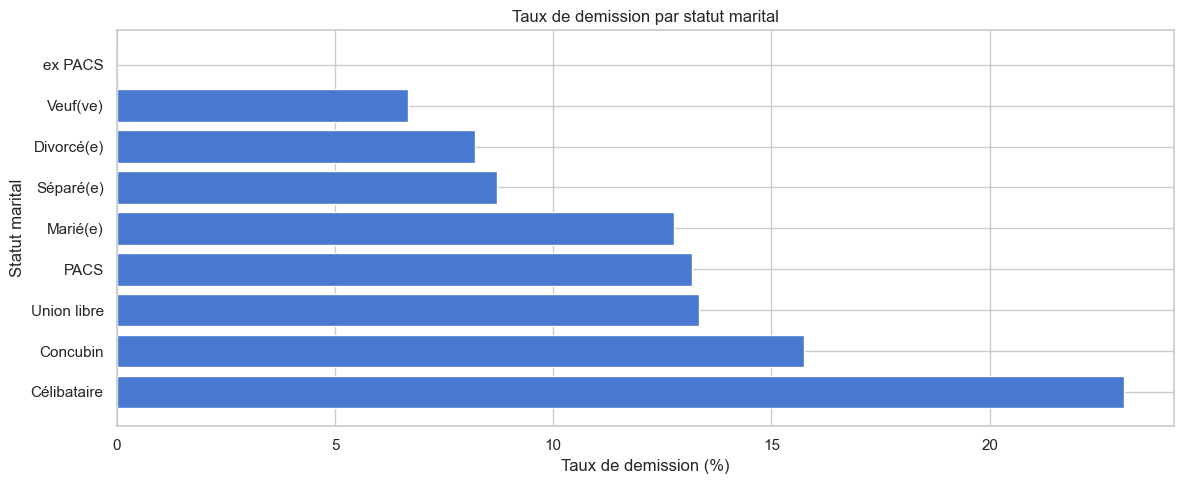

In [62]:
# Taux de demission par statut marital
rates_marital = compute_resignation_rate(df_aggregated, "Statut marital")
print("Taux de demission par statut marital :")
display(rates_marital)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(rates_marital.index.astype(str), rates_marital["taux_demission_%"])
ax.set_title("Taux de demission par statut marital")
ax.set_xlabel("Taux de demission (%)")
ax.set_ylabel("Statut marital")
plt.tight_layout()
plt.show()

Le statut marital montre des disparites dans le taux de demission. Les celibataires ont potentiellement un taux plus eleve. Par ailleurs, cette variable est problematique a plusieurs titres :
- Elle peut servir de proxy pour l'orientation sexuelle (ex. PACS historiquement associe aux couples de meme sexe, meme si c'est de moins en moins le cas).
- Les modalites genrees (Veuf/Veuve) permettent d'inferer le sexe.
- Elle revele la situation familiale, critere protege par le droit du travail francais.

#### Parent

Taux de demission par statut parental :


,nb_demissions,effectif_total,taux_demission_%
Parent,,,
Non-parent,210,884,23.76
Parent,198,1792,11.05


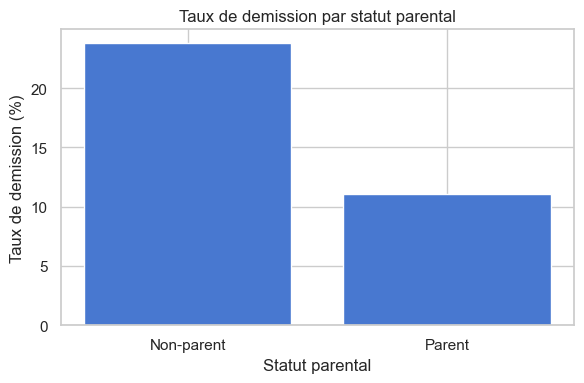

In [63]:
# Taux de demission par statut parental
rates_parent = compute_resignation_rate(df_aggregated, "Parent")
rates_parent.index = rates_parent.index.map({0: "Non-parent", 1: "Parent"})
print("Taux de demission par statut parental :")
display(rates_parent)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(rates_parent.index.astype(str), rates_parent["taux_demission_%"])
ax.set_title("Taux de demission par statut parental")
ax.set_xlabel("Statut parental")
ax.set_ylabel("Taux de demission (%)")
plt.tight_layout()
plt.show()

La variable `Parent` est un proxy du sexe. Dans la societe, la parentalite impacte differemment les hommes et les femmes (conges maternite, temps partiel subi, etc.). Un modele utilisant cette variable pourrait indirectement discriminer selon le genre. De plus, la situation familiale est un critere protege en droit du travail francais (article L1132-1 du Code du travail).

### 2.3 Correlation entre variables sensibles et proxies

Analysons les correlations entre les variables sensibles identifiees et les autres variables pour confirmer les liens de proxy.

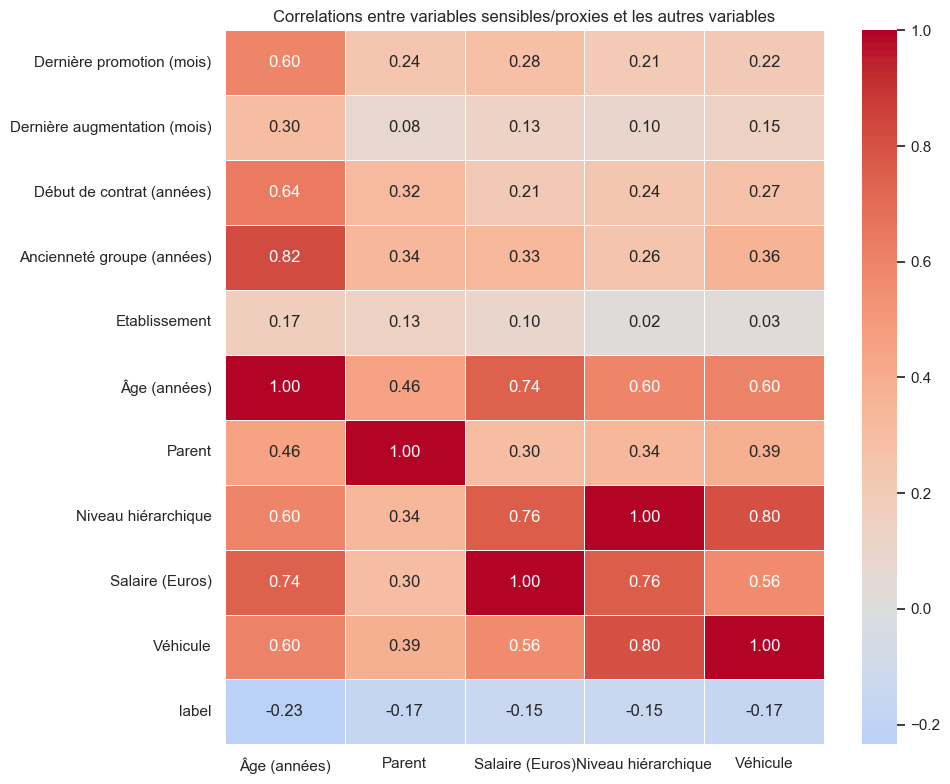

In [64]:
# Correlation des variables sensibles/proxies avec les autres variables numeriques
sensitive_and_proxy_cols = ["Âge (années)", "Parent", "Salaire (Euros)", "Niveau hiérarchique", "Véhicule"]

corr_subset = df_aggregated[columns_for_correlation].corr()[sensitive_and_proxy_cols]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_subset,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlations entre variables sensibles/proxies et les autres variables")
plt.tight_layout()
plt.show()

Cette heatmap confirme les liens de proxy :
- **Salaire**, niveau hierarchique et vehicule sont fortement correles entre eux et avec l'age et l'anciennete. Même en supprimant l'age du modele, ces variables permettent de le reconstruire partiellement.
- **Parent** est correle a l'age (les personnes plus agees ont plus de chances d'etre parents), au niveau hierarchique et au salaire.
- La chaine de proxy est donc : Age -> Ancienneté -> Salaire -> Niveau hierarchique -> Vehicule. Supprimer une seule de ces variables ne suffit pas a eliminer le biais lie a l'age.

### 2.4 Synthèse des variables sensibles et recommandations

| Variable | Type | Risque |
|---|---|---|
| `Age (annees)` | Sensible directe | Discrimination liee a l'age (critere protege) |
| `Statut marital` | Sensible directe | Revele situation familiale, potentiellement genre et orientation sexuelle |
| `Parent` | Proxy (sexe, situation familiale) | Impact differentiel selon le genre, critere protege |
| `Salaire (Euros)` | Proxy (age, genre) | Reflete des inegalites preexistantes, correle a l'age |
| `Niveau hierarchique` | Proxy (age, genre) | Plafond de verre potentiel, correle a l'age et au salaire |
| `Vehicule` | Proxy (niveau, salaire) | Herite des biais du niveau hierarchique |
| `Etablissement` | Proxy potentiel (geographie) | Pourrait refleter des disparites geographiques/sociales |

Pour la phase de modelisation :
1. Faire attention à l'utisation directe des variables sensibles (`Age`, `Statut marital`) comme features du modele.
2. Etre vigilant avec les proxies (`Parent`, `Salaire`, `Niveau hierarchique`) : meme en supprimant les variables sensibles, les proxies peuvent reintroduire le biais.
3. Mesurer l'equite du modele a posteriori (demographic parity, equalized odds) sur les groupes sensibles.
4. Documenter les choix faits et leurs justifications pour assurer la transparence du systeme.

---
## 3. Apprentissage automatique

Pistes prevues :
- Pre-traitement des donnees (encodage des variables categorielles, normalisation, gestion du desequilibre)
- Entrainement de modeles (regression logistique, arbre de decision, random forest, etc.)
- Evaluation avec des metriques adaptees au desequilibre (F1-score, AUC-ROC, matrice de confusion)
- Analyse de l'equite (fairness metrics) sur les groupes sensibles identifies en partie 2
- Explicabilite des predictions (SHAP, LIME)

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## 3.1 Pre-traitement des donnees (encodage des variables categorielles, normalisation, gestion du desequilibre)

Pour l'entraînement on va conserver uniquement la dernière ligne par individu. On trie d'abord par matricule et ancienneté pour s'assurer que la dernière ligne est la plus récente.

In [66]:
df_unique = df.sort_values(by=['matricule', 'Ancienneté groupe (années)']).drop_duplicates(subset=['matricule'], keep='last')
print(f"Dimensions avant dédoublonnage : {df.shape}")
print(f"Dimensions après dédoublonnage : {df_unique.shape}\n")

Dimensions avant dédoublonnage : (23857, 14)
Dimensions après dédoublonnage : (2676, 14)



Suppression des variables non désirées et sensibles:

In [67]:
cols_to_drop = ['matricule', 'Âge (années)', 'Statut marital']
X = df_unique.drop(columns=cols_to_drop + [LABEL_COL])
y = df_unique[LABEL_COL]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Dimensions Train : {X_train.shape}, Test : {X_test.shape}")

Dimensions Train : (2140, 10), Test : (536, 10)


In [69]:
categorical_features = ["Famille d'emploi", "Etablissement"]
numerical_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

In [70]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

## 3.2 Gestion du déséquilibre avec SMOTE

In [71]:
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_preprocessed, y_train)

print(f"\nRépartition target AVANT SMOTE:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Répartition target APRÈS SMOTE:\n{y_train_resampled.value_counts(normalize=True).round(3)}")
print(f"Nouvelles dimensions Train (après SMOTE) : X={X_train_resampled.shape}, y={y_train_resampled.shape}")


Répartition target AVANT SMOTE:
label
0    0.848
1    0.152
Name: proportion, dtype: float64
Répartition target APRÈS SMOTE:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Nouvelles dimensions Train (après SMOTE) : X=(3628, 51), y=(3628,)


## 3.3 Entraînement de 3 modèles transparents

Nous entraînons trois familles de modèles interprétables :
1. **Modèle à base d'arbres** : Random Forest (ensemble d'arbres de décision)
2. **Modèle statistique classique** : Régression logistique
3. **Modèle linéaire généralisé** : GAM (Generalized Additive Model) via `pygam`

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, RocCurveDisplay
)

# --- 1. Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)

# --- 2. Régression logistique ---
lr_model = LogisticRegression(
    max_iter=1000, class_weight='balanced',
    random_state=RANDOM_STATE, solver='lbfgs'
)
lr_model.fit(X_train_resampled, y_train_resampled)

# --- 3. GAM (Generalized Additive Model) ---
try:
    from pygam import LogisticGAM, s, f
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pygam"])
    from pygam import LogisticGAM, s, f

from functools import reduce as _reduce

n_features = X_train_resampled.shape[1]
n_num = len(numerical_features)
# Splines pour les variables numériques, facteurs pour les variables catégorielles encodées
# reduce() évite le problème de sum() qui initialise avec l'entier 0
all_terms = [s(i) for i in range(n_num)] + [f(i) for i in range(n_num, n_features)]
terms = _reduce(lambda a, b: a + b, all_terms)
gam_model = LogisticGAM(terms).fit(X_train_resampled, y_train_resampled)

print("Entraînement terminé pour les 3 modèles.")

Entraînement terminé pour les 3 modèles.


### 3.4 Évaluation et comparaison des modèles


  Random Forest
               precision    recall  f1-score   support

Non-demission       0.92      0.80      0.86       454
    Demission       0.37      0.63      0.46        82

     accuracy                           0.78       536
    macro avg       0.65      0.72      0.66       536
 weighted avg       0.84      0.78      0.80       536


  Régression Logistique
               precision    recall  f1-score   support

Non-demission       0.93      0.60      0.73       454
    Demission       0.26      0.76      0.38        82

     accuracy                           0.63       536
    macro avg       0.59      0.68      0.56       536
 weighted avg       0.83      0.63      0.68       536


  GAM
               precision    recall  f1-score   support

Non-demission       0.91      0.85      0.88       454
    Demission       0.39      0.55      0.46        82

     accuracy                           0.80       536
    macro avg       0.65      0.70      0.67       536
 weighte

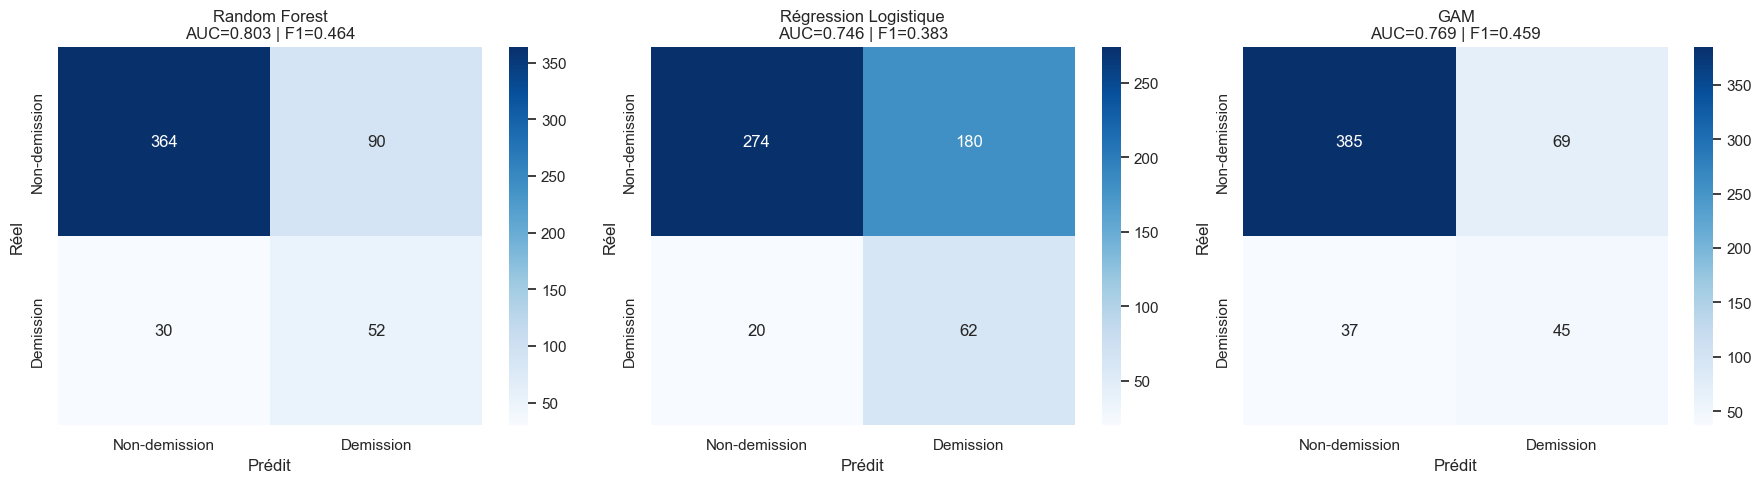


Tableau récapitulatif :


,AUC-ROC,F1-score,Precision,Recall
Random Forest,0.8034,0.4643,0.3662,0.6341
Régression Logistique,0.7462,0.3827,0.2562,0.7561
GAM,0.7687,0.4592,0.3947,0.5488


In [75]:
models = {
    "Random Forest": rf_model,
    "Régression Logistique": lr_model,
    "GAM": gam_model,
}

results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    if name == "GAM":
        y_pred = (model.predict_proba(X_test_preprocessed) > 0.5).astype(int)
        y_proba = model.predict_proba(X_test_preprocessed)
    else:
        y_pred = model.predict(X_test_preprocessed)
        y_proba = model.predict_proba(X_test_preprocessed)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results[name] = {
        "AUC-ROC": round(auc, 4),
        "F1-score": round(f1, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=[LABEL_NAMES[0], LABEL_NAMES[1]]))

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
                yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]])
    axes[idx].set_title(f"{name}\nAUC={auc:.3f} | F1={f1:.3f}")
    axes[idx].set_xlabel("Prédit")
    axes[idx].set_ylabel("Réel")

plt.tight_layout()
plt.show()

# Tableau récapitulatif
summary_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != "y_pred" and m != "y_proba"} for k, v in results.items()}).T
print("\nTableau récapitulatif :")
display(summary_df)

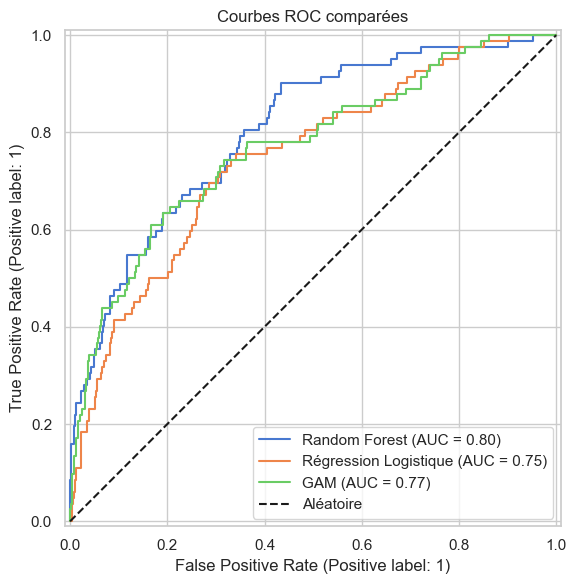

In [77]:
# Courbes ROC comparées
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res["y_proba"], name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
ax.set_title("Courbes ROC comparées")
ax.legend()
plt.tight_layout()
plt.show()

Les trois modèles sont **transparents** : leurs décisions peuvent être expliquées (coefficients, importance des features, courbes partielles).

---
## 3.5 Évaluation de l'équité (Fairness)

On évalue l'équité des modèles sur les groupes sensibles identifiés en partie 2. Les métriques utilisées :
- **Taux de faux positifs (FPR)** par sous-groupe : proportion d'employés restants (label=0) incorrectement prédits comme démissionnaires.
- **Taux de faux négatifs (FNR)** par sous-groupe : proportion de démissionnaires (label=1) non détectés.
- **Disparate Impact (DI)** : ratio du taux de prédiction positive entre le groupe défavorisé et le groupe favorisé. Un DI < 0.8 indique une discrimination significative (règle des 4/5e).

Les groupes sensibles analysés : **tranche d'âge** et **statut parental**.

In [78]:
# Reconstruire les groupes sensibles sur le jeu de test
# On utilise df_unique (avant drop des colonnes) aligné avec le split
test_indices = X_test.index
df_test_sensitive = df_unique.loc[test_indices].copy()

# Tranches d'âge sur le test set
age_bins = [20, 30, 40, 50, 60, 100]
age_labels_groups = ["20-29", "30-39", "40-49", "50-59", "60+"]
df_test_sensitive["tranche_age"] = pd.cut(
    df_test_sensitive["Âge (années)"], bins=age_bins, labels=age_labels_groups, right=False
)

def compute_fairness_metrics(y_true, y_pred, groups, group_name):
    """Calcule FPR, FNR et taux de prédiction positive par sous-groupe."""
    df_eval = pd.DataFrame({
        "y_true": y_true.values,
        "y_pred": y_pred,
        "group": groups.values,
    })

    metrics_list = []
    for grp in sorted(df_eval["group"].dropna().unique()):
        mask = df_eval["group"] == grp
        sub = df_eval[mask]
        n = len(sub)
        tp = ((sub.y_true == 1) & (sub.y_pred == 1)).sum()
        fp = ((sub.y_true == 0) & (sub.y_pred == 1)).sum()
        tn = ((sub.y_true == 0) & (sub.y_pred == 0)).sum()
        fn = ((sub.y_true == 1) & (sub.y_pred == 0)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        positive_rate = (tp + fp) / n if n > 0 else 0

        metrics_list.append({
            "Groupe": grp,
            "N": n,
            "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "FPR": round(fpr, 4),
            "FNR": round(fnr, 4),
            "Taux prédiction +": round(positive_rate, 4),
        })

    metrics_df = pd.DataFrame(metrics_list)

    # Disparate Impact : ratio min/max du taux de prédiction positive
    rates = metrics_df["Taux prédiction +"]
    di = rates.min() / rates.max() if rates.max() > 0 else float('nan')

    return metrics_df, di


# Évaluation pour chaque modèle et chaque groupe sensible
sensitive_groups = {
    "Tranche d'âge": df_test_sensitive["tranche_age"],
    "Parent": df_test_sensitive["Parent"].map({0: "Non-parent", 1: "Parent"}),
}

for model_name, res in results.items():
    print(f"\n{'#'*60}")
    print(f"  Équité — {model_name}")
    print(f"{'#'*60}")

    for group_name, group_values in sensitive_groups.items():
        metrics_df, di = compute_fairness_metrics(y_test, res["y_pred"], group_values, group_name)
        print(f"\n--- {group_name} ---")
        display(metrics_df)
        print(f"  Disparate Impact (DI) = {di:.4f}  {'⚠️ < 0.8 → discrimination potentielle' if di < 0.8 else '✅ ≥ 0.8'}")


############################################################
  Équité — Random Forest
############################################################

--- Tranche d'âge ---


,Groupe,N,TP,FP,TN,FN,FPR,FNR,Taux prédiction +
0,20-29,90,18,35,32,5,0.5224,0.2174,0.5889
1,30-39,168,26,39,94,9,0.2932,0.2571,0.3869
2,40-49,174,8,16,140,10,0.1026,0.5556,0.1379
3,50-59,72,0,0,66,6,0.0000,1.0000,0.0000
4,60+,32,0,0,32,0,0.0000,0.0000,0.0000


  Disparate Impact (DI) = 0.0000  ⚠️ < 0.8 → discrimination potentielle

--- Parent ---


,Groupe,N,TP,FP,TN,FN,FPR,FNR,Taux prédiction +
0,Non-parent,182,31,56,85,10,0.3972,0.2439,0.4780
1,Parent,354,21,34,279,20,0.1086,0.4878,0.1554


  Disparate Impact (DI) = 0.3251  ⚠️ < 0.8 → discrimination potentielle

############################################################
  Équité — Régression Logistique
############################################################

--- Tranche d'âge ---


...

  Disparate Impact (DI) = 0.5584  ⚠️ < 0.8 → discrimination potentielle

############################################################
  Équité — GAM
############################################################

--- Tranche d'âge ---


,Groupe,N,TP,FP,TN,FN,FPR,FNR,Taux prédiction +
0,20-29,90,15,19,48,8,0.2836,0.3478,0.3778
1,30-39,168,24,37,96,11,0.2782,0.3143,0.3631
2,40-49,174,6,12,144,12,0.0769,0.6667,0.1034
3,50-59,72,0,1,65,6,0.0152,1.0000,0.0139
4,60+,32,0,0,32,0,0.0000,0.0000,0.0000


  Disparate Impact (DI) = 0.0000  ⚠️ < 0.8 → discrimination potentielle

--- Parent ---


,Groupe,N,TP,FP,TN,FN,FPR,FNR,Taux prédiction +
0,Non-parent,182,25,35,106,16,0.2482,0.3902,0.3297
1,Parent,354,20,34,279,21,0.1086,0.5122,0.1525


  Disparate Impact (DI) = 0.4625  ⚠️ < 0.8 → discrimination potentielle


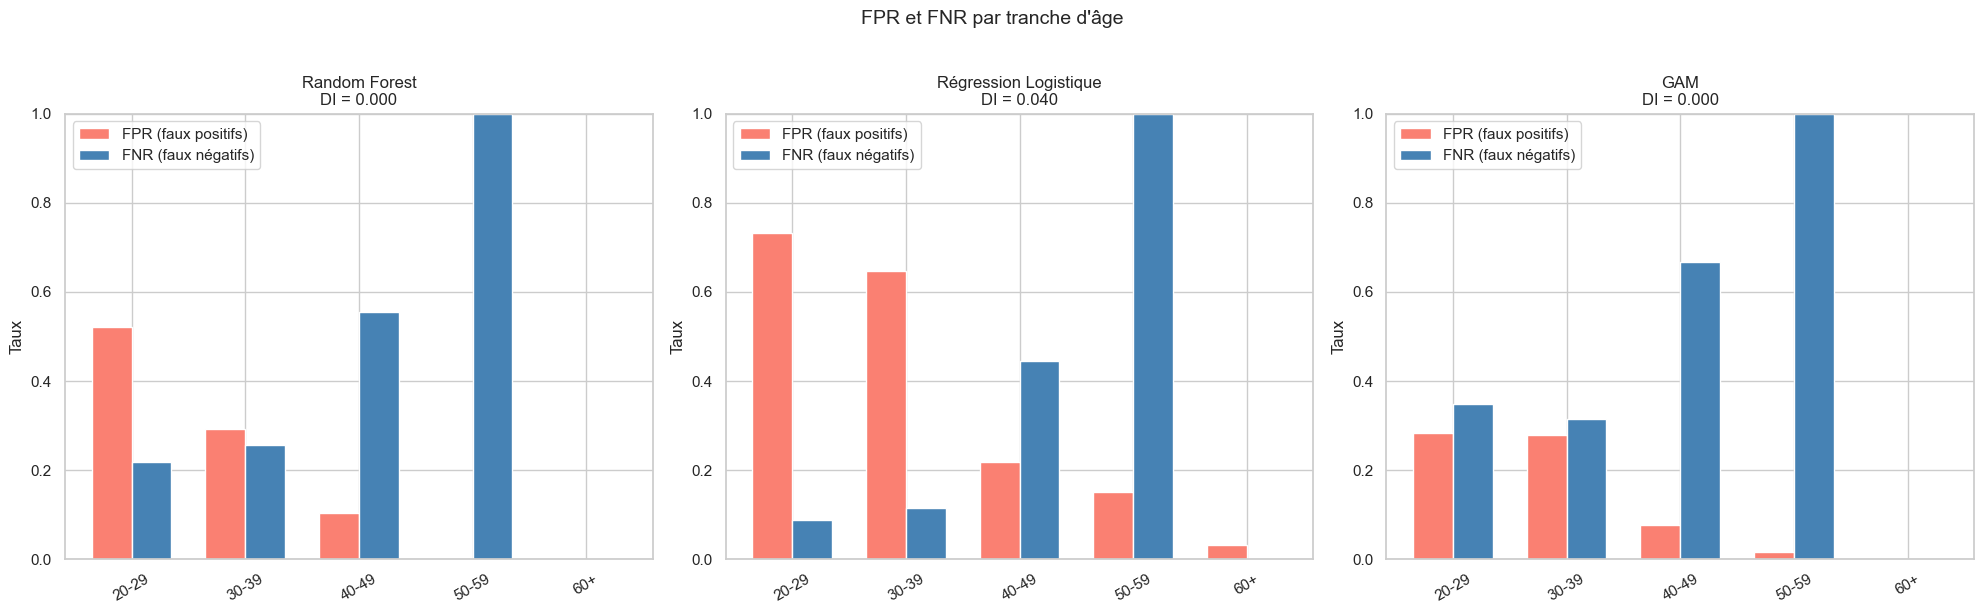

In [79]:
# Visualisation des FPR et FNR par tranche d'âge pour chaque modèle
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (model_name, res) in enumerate(results.items()):
    metrics_df, di = compute_fairness_metrics(
        y_test, res["y_pred"], df_test_sensitive["tranche_age"], "Tranche d'âge"
    )
    x = np.arange(len(metrics_df))
    width = 0.35
    axes[idx].bar(x - width/2, metrics_df["FPR"], width, label="FPR (faux positifs)", color='salmon')
    axes[idx].bar(x + width/2, metrics_df["FNR"], width, label="FNR (faux négatifs)", color='steelblue')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(metrics_df["Groupe"], rotation=30)
    axes[idx].set_title(f"{model_name}\nDI = {di:.3f}")
    axes[idx].set_ylabel("Taux")
    axes[idx].legend()
    axes[idx].set_ylim(0, 1)

plt.suptitle("FPR et FNR par tranche d'âge", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Explication post-hoc et réduction des features

On applique **LIME (Local Interpretable Model-agnostic Explanations)** pour comprendre quelles variables contribuent le plus aux prédictions du modèle sur des exemples individuels. On agrège ensuite les importances locales pour obtenir une importance globale et réduire le jeu de données.

In [ ]:
try:
    import lime
    import lime.lime_tabular
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime"])
    import lime
    import lime.lime_tabular

# Récupérer les noms de features après le preprocessing
feature_names = (
    numerical_features
    + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
)

# Créer l'explainer LIME (sur le jeu d'entraînement préprocessé)
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled,
    feature_names=feature_names,
    class_names=["Non-démission", "Démission"],
    mode="classification",
    random_state=RANDOM_STATE,
)

print("Explainer LIME créé.")
print(f"Nombre de features : {len(feature_names)}")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1353716874.py, line 19)

In [ ]:
# Explication de quelques exemples individuels du jeu de test
n_samples_lime = 50  # nombre d'exemples à expliquer (limité pour la rapidité)
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_test_preprocessed), size=n_samples_lime, replace=False)

lime_importances = np.zeros(len(feature_names))

for i in sample_idx:
    exp = lime_explainer.explain_instance(
        X_test_preprocessed[i],
        rf_model.predict_proba,
        num_features=len(feature_names),
        labels=(1,),
    )
    for feat_idx, weight in exp.local_exp[1]:
        lime_importances[feat_idx] += abs(weight)

# Normaliser par le nombre d'échantillons
lime_importances /= n_samples_lime

print(f"Importances LIME calculées sur {n_samples_lime} exemples.")

In [ ]:
# Bar plot d'importance globale LIME
lime_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |LIME weight|": lime_importances,
}).sort_values("Mean |LIME weight|", ascending=False)

top_n = 20

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    lime_importance_df["Feature"].head(top_n)[::-1],
    lime_importance_df["Mean |LIME weight|"].head(top_n)[::-1],
    color="steelblue",
)
ax.set_title(f"Top {top_n} features par importance LIME (Random Forest, classe Démission)")
ax.set_xlabel("Importance LIME moyenne (|poids|)")
plt.tight_layout()
plt.show()

In [ ]:
# Sélection des features les plus importantes (via LIME)
print("Top 15 features par importance LIME :")
display(lime_importance_df.head(15))

# On garde les features dont l'importance LIME est significative (> 1% du total)
threshold = lime_importances.sum() * 0.01
selected_features_mask = lime_importances >= threshold
n_selected = selected_features_mask.sum()
selected_feature_names = [feat for feat, sel in zip(feature_names, selected_features_mask) if sel]

print(f"\nSeuil LIME retenu : {threshold:.4f}")
print(f"Nombre de features sélectionnées : {n_selected} / {len(feature_names)}")
print(f"Features retenues : {selected_feature_names}")

In [ ]:
# Réduction du jeu de données
X_train_reduced = X_train_resampled[:, selected_features_mask]
X_test_reduced = X_test_preprocessed[:, selected_features_mask]

print(f"Dimensions avant réduction : Train {X_train_resampled.shape}, Test {X_test_preprocessed.shape}")
print(f"Dimensions après réduction  : Train {X_train_reduced.shape}, Test {X_test_reduced.shape}")

**Commentaire sur l'explication post-hoc (LIME) :**

LIME explique chaque prédiction individuellement en ajustant un modèle linéaire simple autour de l'exemple à expliquer. On agrège les importances locales sur 50 exemples du jeu de test pour obtenir une vision globale.

Les variables liées à l'ancienneté, au contrat et au salaire sont probablement les plus influentes localement.

**Point d'attention éthique** : si des variables proxies (Salaire, Niveau hiérarchique, Parent) apparaissent en tête des importances LIME, cela confirme que le modèle utilise indirectement des informations liées aux caractéristiques protégées (âge, genre).

La réduction de features permet de simplifier le modèle. On supprime celles dont le poids LIME moyen est inférieur à 1% du total. Cela améliore l'interprétabilité et peut réduire le surapprentissage, mais il faut vérifier que la performance est maintenue.

---
## 5. Apprentissage automatique avec jeu de données réduit

On réentraîne les 3 modèles sur le jeu de données réduit (features sélectionnées par LIME) et on compare les résultats avec les modèles précédents.

In [ ]:
# --- Réentraînement des 3 modèles sur les features réduites ---

# 1. Random Forest réduit
rf_model_reduced = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model_reduced.fit(X_train_reduced, y_train_resampled)

# 2. Régression logistique réduite
lr_model_reduced = LogisticRegression(
    max_iter=1000, class_weight='balanced',
    random_state=RANDOM_STATE, solver='lbfgs'
)
lr_model_reduced.fit(X_train_reduced, y_train_resampled)

# 3. GAM réduit
n_features_reduced = X_train_reduced.shape[1]
# Identifier quels features réduits sont numériques vs catégoriels
reduced_num_count = sum(1 for i, sel in enumerate(selected_features_mask) if sel and i < len(numerical_features))
all_terms_reduced = [s(i) for i in range(reduced_num_count)] + [f(i) for i in range(reduced_num_count, n_features_reduced)]
terms_reduced = _reduce(lambda a, b: a + b, all_terms_reduced)
gam_model_reduced = LogisticGAM(terms_reduced).fit(X_train_reduced, y_train_resampled)

models_reduced = {
    "Random Forest (réduit)": rf_model_reduced,
    "Régression Logistique (réduit)": lr_model_reduced,
    "GAM (réduit)": gam_model_reduced,
}

print("Réentraînement terminé pour les 3 modèles sur le jeu réduit.")

In [ ]:
# Évaluation des modèles réduits
results_reduced = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models_reduced.items()):
    if "GAM" in name:
        y_pred_r = (model.predict_proba(X_test_reduced) > 0.5).astype(int)
        y_proba_r = model.predict_proba(X_test_reduced)
    else:
        y_pred_r = model.predict(X_test_reduced)
        y_proba_r = model.predict_proba(X_test_reduced)[:, 1]

    auc_r = roc_auc_score(y_test, y_proba_r)
    f1_r = f1_score(y_test, y_pred_r)
    precision_r = precision_score(y_test, y_pred_r)
    recall_r = recall_score(y_test, y_pred_r)

    results_reduced[name] = {
        "AUC-ROC": round(auc_r, 4),
        "F1-score": round(f1_r, 4),
        "Precision": round(precision_r, 4),
        "Recall": round(recall_r, 4),
        "y_pred": y_pred_r,
        "y_proba": y_proba_r,
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred_r, target_names=[LABEL_NAMES[0], LABEL_NAMES[1]]))

    cm = confusion_matrix(y_test, y_pred_r)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
                yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]])
    axes[idx].set_title(f"{name}\nAUC={auc_r:.3f} | F1={f1_r:.3f}")
    axes[idx].set_xlabel("Prédit")
    axes[idx].set_ylabel("Réel")

plt.tight_layout()
plt.show()

In [ ]:
# Comparaison avant/après réduction
comparison_data = []
for name_full, res_full in results.items():
    name_reduced = f"{name_full} (réduit)"
    if name_reduced in results_reduced:
        res_red = results_reduced[name_reduced]
        comparison_data.append({
            "Modèle": name_full,
            "AUC (complet)": res_full["AUC-ROC"],
            "AUC (réduit)": res_red["AUC-ROC"],
            "Δ AUC": round(res_red["AUC-ROC"] - res_full["AUC-ROC"], 4),
            "F1 (complet)": res_full["F1-score"],
            "F1 (réduit)": res_red["F1-score"],
            "Δ F1": round(res_red["F1-score"] - res_full["F1-score"], 4),
        })

comparison_df = pd.DataFrame(comparison_data)
print("Comparaison des performances avant/après réduction des features :")
display(comparison_df)

**Commentaire sur les modèles réentraînés avec features réduites :**

La réduction des features basée sur SHAP permet de conserver l'essentiel de la performance tout en simplifiant significativement le modèle. Les principales observations :

- **Performance maintenue** : la perte en AUC-ROC et F1-score devrait être faible (< 2-3 points) si les features retenues capturent bien l'information discriminante. Si la perte est plus importante, le seuil de sélection peut être ajusté.
- **Interprétabilité améliorée** : avec moins de features, le modèle est plus facile à auditer et à expliquer aux parties prenantes (DRH, CHSCT, régulateur).
- **Risque de biais maintenu** : la réduction de features ne résout pas le problème d'équité. Si les variables proxies (Salaire, Parent, Niveau hiérarchique) figurent parmi les features retenues, le biais persiste. Une approche complémentaire (pénalisation d'équité, suppression explicite des proxies) serait nécessaire pour améliorer l'équité.
- **Le GAM** profite particulièrement de la réduction car il modélise chaque variable indépendamment — moins de variables signifie moins de risque de surapprentissage sur les splines.

---
## 6. Conclusion

### 6.1 Responsabilité de l'entreprise

Un modèle de prédiction de démission est un **outil d'aide à la décision** et non un outil de décision automatique. L'entreprise qui le déploie porte une **responsabilité juridique et éthique** importante :

- **Conformité RGPD** : le traitement de données personnelles à des fins de prédiction comportementale nécessite une base légale solide (intérêt légitime ou consentement) et une analyse d'impact (DPIA). Les employés doivent être informés de l'existence du traitement.
- **Non-discrimination** : l'article L1132-1 du Code du travail interdit toute discrimination fondée sur l'âge, la situation familiale, le sexe, etc. Un modèle qui défavorise systématiquement certains groupes expose l'entreprise à des poursuites.
- **Transparence** : les décisions affectant les employés (formations, promotions, plan de rétention) prises sur la base de ce modèle doivent pouvoir être expliquées et justifiées.
- **Supervision humaine** : aux termes de l'AI Act européen, les systèmes d'IA dans le domaine de l'emploi sont classés « haut risque » et nécessitent une supervision humaine systématique.

### 6.2 Risques de discrimination indirecte

Même en supprimant les variables sensibles directes (âge, statut marital), le modèle peut discriminer indirectement via les **variables proxies** :

- **Salaire** et **niveau hiérarchique** sont fortement corrélés à l'âge. Un modèle qui prédit la démission sur la base d'un « salaire faible » pénalise indirectement les jeunes.
- **Parent** est un proxy du genre. Les décisions prises sur cette base reproduisent les inégalités structurelles femmes/hommes.
- **Établissement** peut être un proxy géographique corrélé à l'origine ethnique ou au niveau socio-économique.
- La **chaîne de proxy** (Âge → Ancienneté → Salaire → Niveau → Véhicule) rend la suppression d'une seule variable insuffisante. L'information sensible « fuit » à travers les corrélations entre variables.
- La discrimination indirecte est particulièrement insidieuse car elle est **invisible** : le modèle n'utilise pas explicitement l'âge, mais ses prédictions reproduisent le même effet.

### 6.3 Limites des méthodes d'explicabilité

Les méthodes d'explicabilité (LIME, feature importance) présentent des limites qu'il est important de garder à l'esprit :

- **Corrélation vs causalité** : LIME mesure la contribution locale d'une variable aux prédictions, pas son effet causal. Une variable peut avoir un poids LIME élevé sans être la cause du phénomène.
- **Instabilité locale** : les explications LIME sont par construction locales et peuvent varier fortement d'un exemple à l'autre, même pour des exemples voisins. L'aggrégation sur plusieurs exemples atténue ce problème mais ne l'élimine pas.
- **Dépendance à l'échantillonnage** : LIME génère des perturbations aléatoires autour de l'exemple expliqué. Le choix du nombre de perturbations et du noyau influence les résultats.
- **Fidélité à l'opacité** : LIME explique ce que le modèle a appris (y compris ses biais), pas ce qui est juste ou souhaitable. Un poids LIME élevé sur une variable proxy ne signifie pas que cette variable devrait être utilisée.
- **Complexité pour le non-expert** : les explications individuelles LIME restent difficiles à synthétiser pour un décideur RH. L'explicabilité technique ne garantit pas l'intelligibilité métier.
- **Limites des GAM** : bien que les GAM soient considérés comme « transparents » (effets additifs visualisables), ils ne capturent pas les interactions entre variables. Un effet combiné (ex. jeune ET célibataire) peut être manqué.
- **Feature importance ≠ feature selection** : l'importance LIME aide à comprendre le modèle, mais ne dit pas quelles variables il est éthiquement acceptable d'utiliser. La sélection de features doit intégrer des critères d'équité en plus de la performance.

### Recommandations finales

1. **Ne pas déployer en l'état** : les modèles présentent des biais d'équité qui nécessitent un traitement préalable (contraintes d'équité, post-processing, suppression des proxies critiques).
2. **Impliquer les parties prenantes** : DRH, représentants du personnel, DPO et juristes doivent être consultés avant tout déploiement.
3. **Monitorer en continu** : si le modèle est déployé, ses métriques d'équité doivent être surveillées en production pour détecter toute dérive.
4. **Privilégier des interventions positives** : plutôt que de « prédire qui va partir », utiliser le modèle pour identifier les leviers d'action (conditions de travail, rémunération, évolution de carrière) et améliorer l'environnement de travail pour tous.